---
title: "Butler–Volmer kinetics, and where its two limits stop being safe"
description: "The interfacial charge-transfer law in the form a reactor model uses it, read off Doyle, Fuller and Newman (1993) — the exchange current density derived from their own equations, and the overpotential at which the Tafel and linear approximations go wrong by 1, 5 and 10 %."
categories: [sec:J, struct:S1, tier:T0, data:tier6, phase:liquid-solid]
date: 2026-07-31
---

# Butler–Volmer kinetics, and where its two limits stop being safe

**Catalog ID:** `J3.1` · **Structures:** `S1` (algebraic constitutive law) ·
**Tier:** T0

Almost every electrochemical reactor model contains one nonlinear algebraic
equation that turns a potential difference into a current density. Almost every
one of them is then simplified — to a linear resistance, or to a single
exponential — and the simplification is usually made without checking. This page
does the checking, and puts numbers on it.

## Background

### What this page is a page *of*, and what it is not

The Butler–Volmer equation is conventionally attributed to Tafel (1905), to
J. A. V. Butler (1924, 1932) and to Erdey-Grúz and Volmer (1930). **None of
those papers was consulted for this page**, none is available here, and their
bibliographic details are recorded from secondary attribution only, without a
DOI, precisely because an unverified citation is worse than none. Nothing on
this page is a restatement of a source that was not read.

What *was* read is **Doyle, Fuller and Newman (1993)**, *J. Electrochem. Soc.*
**140**(6) 1526–1533, which prints the law in exactly the form a reactor model
uses it, twice: once as the general two-exponential kinetics of a flat electrode
(their **Eq. 6**, with the exchange current density of **Eq. 8**), and once as a
mass-action expression for an insertion reaction (their **Eq. 17**, with the
exchange current density of **Eq. 30**). That paper is the source of the
gallery's [`J3.4`](../J3.4-doyle-fuller-newman/) page, so its parameter set has
already been extracted from 600 dpi page renders and reviewed, and its
open-circuit expression has already been validated against the authors' own
plotted curve to 3.3 mV. Everything algebraic here starts from those printed
equations.

A second paper on disk, **Marquis, Sulzer, Timms, Please and Chapman (2019)**
(*J. Electrochem. Soc.* **166**(15) A3693–A3706, the source of
[`J3.5`](../J3.5-single-particle-model/)), prints the same kinetics in its
hyperbolic-sine form and prints the closed-form inversion. That gives a second,
independent printed witness for two of the identities below.

### Why this is a separate page from `J3.4`

`J3.4` *uses* Eq. 17 inside a full pseudo-two-dimensional cell; it never looks at
the law itself. It does not derive the exchange current density, does not ask
what happens when the two transfer coefficients do not sum to one, and does not
touch either limit — its `arcsinh` is the exact inversion of the symmetric law,
not an approximation to it. This page is about the constitutive law: what its
parameters mean, which of its features are identities rather than choices, and —
the part that is worth more than any restatement — **the overpotential at which
each of its two standard approximations goes wrong by a stated amount**, checked
against the overpotentials that the published `J3.4` cell actually operates at.

Two honest qualifications, neither of which changes that.

* **Part of the algebra is already in the repository, unremarked.** `J3.5`'s
  `bv_invert` is a closed-form inversion of Eq. 17 whose structure silently
  *contains* the reduction derived below: at zero current its root is Eq. 16
  exactly, and its exchange prefactor is Eq. 30's. `J3.5` never says so, never
  states the $\alpha_a+\alpha_c=1$ condition it depends on, and never uses it as
  a check — but a reader who knows that page should know the algebra is not new
  to the gallery, only unexamined in it.
* **One number here already exists elsewhere on a different scale.** `J3.5`'s
  `C_r_doyle` is the same interfacial-versus-superficial ratio this page uses to
  classify the cathode, and reports it as $\sim10^{-4}$ against the $1.0\times
  10^{-3}$ here. The two are not in conflict; they divide by different exchange
  current densities, and the ratio between them is computed in the Reuse section
  below.

The answer for that cell is not the one most readers would guess, and it is
different at its two electrodes.

## The published model

### The law, as printed

Doyle, Fuller and Newman write the kinetics of the lithium foil as (their
**Eq. 6**, with the surface overpotential $\eta_{s1}=\Phi_1-\Phi_2-U_1$ of
**Eq. 7**)

$$
I = i_{o1}\left[\exp\!\left(\frac{\alpha_{a1}F\eta_{s1}}{RT}\right)
-\exp\!\left(-\frac{\alpha_{c1}F\eta_{s1}}{RT}\right)\right],
\tag{6}
$$

$$
i_{o1} = F(k_{a1})^{\alpha_{c1}}(k_{c1})^{\alpha_{a1}}
(c_{\max}-c)^{\alpha_{c1}}(c)^{\alpha_{a1}}.
\tag{8}
$$

That is the Butler–Volmer equation. The insertion reaction at the porous cathode
is written in mass-action form instead (their **Eq. 17**, with $U'$ of Eq. 18 and
$\eta=\Phi_1-\Phi_2$ of Eq. 19):

$$
i = Fk_2(c_{\max}-c)^{\alpha_c}c^{\alpha_A}
\left[c_s\exp\!\left(\frac{\alpha_aF}{RT}(\eta-U')\right)
-(c_T-c_s)\exp\!\left(-\frac{\alpha_cF}{RT}(\eta-U')\right)\right],
\tag{17}
$$

$$
U' = U_2^{\theta}-U_{\rm ref}^{\theta}+\frac{RT}{F}(\beta c_s+\zeta).
\tag{18}
$$

Both were read off 600 dpi renders of journal pages 1527 and 1528; the scan's
text layer mangles them beyond use (Eq. 17 comes out as
`i = Fk2(emax - c)~~ ... ~R~01 - U'))`). The exponent printed on $c$ in Eq. 17 is
typeset `α_A`; it is $\alpha_a$, and the check in the next section proves it,
because no other reading reproduces the paper's own Eq. 30.

Separately, the paper prints the **open-circuit potential** of the insertion
material (their **Eq. 16**)

$$
U_2 = U_2^{\theta}-U_{\rm ref}^{\theta}
+\frac{RT}{F}\left(\ln\frac{c_T-c_s}{c_s}+\beta c_s+\zeta\right)
= U' + \frac{RT}{F}\ln\frac{c_T-c_s}{c_s},
\tag{16}
$$

and the **exchange current density** of the insertion reaction (their **Eq. 30**)

$$
i_{o2} = F(k_2)(c_{\max}-c)^{\alpha_{c2}}(c)^{\alpha_{a2}}
(c_T-c_s)^{\alpha_{a2}}(c_s)^{\alpha_{c2}}.
\tag{30}
$$

Eqs. 16, 17 and 30 are printed in three different places, eleven journal pages
apart in the case of the last two, and are **not** derived from one another in
the paper. They therefore constitute an internal identity, and it is the
strongest check available here.

### The identity that ties them together

Put $\eta_s = \eta - U_2$ — the *surface* overpotential, measured from the local
equilibrium potential rather than from the reference — and substitute Eq. 16 into
Eq. 17. The bracket becomes

$$
c_s\left(\tfrac{c_T-c_s}{c_s}\right)^{\alpha_a}
e^{\alpha_a F\eta_s/RT}
-(c_T-c_s)\left(\tfrac{c_T-c_s}{c_s}\right)^{-\alpha_c}
e^{-\alpha_c F\eta_s/RT},
$$

whose two prefactors are $c_s^{1-\alpha_a}(c_T-c_s)^{\alpha_a}$ and
$c_s^{\alpha_c}(c_T-c_s)^{1-\alpha_c}$. **They are equal if and only if**
$\alpha_a+\alpha_c=1$, and when they are, Eq. 17 collapses to

$$
i = i_{o2}\left[e^{\alpha_aF\eta_s/RT}-e^{-\alpha_cF\eta_s/RT}\right],
\qquad
i_{o2}=Fk_2(c_{\max}-c)^{\alpha_c}c^{\alpha_a}(c_T-c_s)^{\alpha_a}c_s^{\alpha_c},
$$

which is Doyle's Eq. 30 as printed, factor by factor and exponent by exponent —
including which of $\alpha_a$ and $\alpha_c$ sits on which concentration, the
detail a transcription is most likely to get wrong. It is also Eq. 6 with a
different exchange current density, which is what makes Eq. 6 and Eq. 17 the same
law.

Read as a *check*, though, the agreement is narrower than the derivation. The
$(c_{\max}-c)^{\alpha_c}c^{\alpha_a}$ prefactor is the same code expression on
both sides and cancels in the ratio, so the numerical comparison tests only the
$(c_T-c_s)^{\alpha_a}c_s^{\alpha_c}$ half against Eq. 17's bracket. And **at
Doyle's own $\alpha_a=\alpha_c=\tfrac12$ every exponent swap is a no-op**, so
none of it bites at the published parameters. What gives the check its power is
the asymmetric rows of the sweep below. Both statements are measured, not
asserted, in the injected-defect table that follows Check 2.

Three consequences, all checked numerically below:

1. **The zero-current potential of Eq. 17 equals Eq. 16 only when
   $\alpha_a+\alpha_c=1$.** Otherwise the kinetics and the thermodynamics of the
   same paper disagree, by $\frac{RT}{F}\ln\frac{c_T-c_s}{c_s}
   \left(\frac{1}{\alpha_a+\alpha_c}-1\right)$. This is a real constraint on the
   model, not an accident of notation, and it is why $\alpha_a+\alpha_c$ appears
   rather than $\alpha_a$ alone in the paper's own Eq. 29.
2. **An exchange current density exists only under the same condition.** For
   $\alpha_a+\alpha_c\ne1$ the two branches have different prefactors and no
   single $i_0$ can be factored out — Eq. 30 would then not be well defined.
3. Doyle's Table II has $\alpha_a=\alpha_c=0.5$, so the condition holds for the
   published cell and Eq. 30 is what the paper says it is.

### The two limits

With $\alpha_a+\alpha_c=1$ (write $n=\alpha_a+\alpha_c$ for the general case):

**Linear.** Expanding about $\eta_s=0$,
$i \to i_0\,\frac{nF}{RT}\,\eta_s$, i.e. a pure resistance

$$
R_{\rm ct} = \left(\frac{\partial i}{\partial\eta_s}\right)^{-1}_{\eta_s=0}
= \frac{RT}{nFi_0}.
$$

The familiar textbook form $RT/(nFi_0)$ is therefore an identity only when the
transfer coefficients sum to the electron number. That is an assumption, not a
theorem, and the page states it rather than assuming it.

**Tafel.** For $\eta_s$ large and positive the cathodic term dies and
$i\to i_0e^{\alpha_aF\eta_s/RT}$, so a plot of $\eta_s$ against $\log_{10}i$ is a
straight line of slope

$$
b = \frac{\ln 10\;RT}{\alpha_a F}\quad(\text{anodic}),\qquad
b = -\frac{\ln 10\;RT}{\alpha_c F}\quad(\text{cathodic}).
$$

**Symmetric case.** When $\alpha_a=\alpha_c=\alpha$ the law is
$i = 2i_0\sinh(\alpha F\eta_s/RT)$, which inverts in closed form,

$$
\eta_s = \frac{RT}{\alpha F}\,\operatorname{arcsinh}\!\frac{i}{2i_0}.
$$

Marquis et al. print both of these (their **Eqs. 1g–1h** for the hyperbolic-sine
law and its exchange current density, and their **Eq. 18** for the inversion, in
dimensionless form with $\alpha=\tfrac12$), and the `J3.4` page already uses the
inversion for its lithium foil. It is checked below by feeding the closed form
forward through the printed Eq. 17.

## Parameters and assumptions

**Assumptions built into the law itself**, all of them stated by Doyle et al.:
a single elementary charge-transfer step; potential-independent transfer
coefficients; concentrations at the reacting interface, not in the bulk (any
mass-transfer resistance is outside the law); an ideal solution, "because
activity coefficient data have not been reported"; isothermal operation; and no
surface film. The insertion form additionally assumes site-limited kinetics on
both sides of the interface, which is where the $(c_{\max}-c)$ and $(c_T-c_s)$
factors come from.

**Numerical inputs** are Doyle's Table II, Appendix A and Eq. 20, loaded
**cross-page** from the reviewed `J3.4` dataset rather than re-extracted. The
relevant ones are $k_2=10^{-10}$ m⁴/(mol s), $\alpha_a=\alpha_c=0.5$,
$c_T=29\,000$ mol/m³, $c_{\max}=3920$ mol/m³, $c_0=1000$ mol/m³, $T=373.15$ K,
and $i_{o1}=12.6$ A/m² for the lithium foil. Note the temperature: this cell runs
at 100 °C, so $RT/F=32.15$ mV rather than the 25.69 mV of room temperature, and
every threshold below scales with it. Both are reported.

**One thing this page deliberately does not decide.** `J3.4` records an open
question about the factor $\nu=2$ in the concentration term of Doyle's Eq. 5:
thermodynamics requires it for a 1:1 salt, the printed equation omits it, and the
paper's Figure 2 cannot separate the two. That question is about the electrolyte
potential, not about the kinetics. Where the cell is solved below it is solved
**both ways**, and the kinetic conclusions are reported for both, so nothing here
depends on the answer.

**Provenance tier 6.** Nothing on this page is compared with a measurement.
Doyle's Figure 2 contains no experimental points at all — confirmed by the
gallery maintainer on review of the original — and the checks here are algebraic
identities plus the paper's own printed numbers. This page is *reproduced* and
*internally verified*; it is **not** validated against experiment, and the two
must not be blurred.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.optimize import brentq
from scipy.sparse.linalg import MatrixRankWarning
from pymrm import construct_grad, construct_div, NumJac, newton, stencil_block_diagonals
from gallery_utils import load_data, load_meta, cite_data, report_agreement

warnings.filterwarnings("ignore", category=MatrixRankWarning)
PAGE_J34 = "J3.4-doyle-fuller-newman"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

R_GAS, F_CONST = 8.3143, 96487.0     # as used on J3.4 (Doyle-era constants)

## The data

**This page ships no dataset of its own, and digitises no figure.** It has
nothing to digitise: the result is an algebraic law and its limits, and the only
numbers that enter come from Doyle's tables and running text.

Two files are loaded cross-page from `J3.4`, whose provenance sidecars carry the
full extraction record:

* `doyle-fuller-newman-1993-parameters.csv` — Tables I and II, Appendix A and the
  Eq. 20 constants, every value read off a 600 dpi render;
* `doyle-fuller-newman-1993-stated-results.csv` — the scalar results Doyle prints
  in running text, of which $\delta=1.95$ and $\nu=68$ are used here as a
  printed-number check on Eq. 30.

In [3]:
par = load_data("doyle-fuller-newman-1993-parameters.csv", page=PAGE_J34)
stated = load_data("doyle-fuller-newman-1993-stated-results.csv", page=PAGE_J34)
par_meta = load_meta("doyle-fuller-newman-1993-parameters.csv", page=PAGE_J34)

P = {r.symbol: float(r.value) for r in par.itertuples()}
S = {r.quantity: float(r.value) for r in stated.itertuples()}
T = P["T"]
RTF = R_GAS * T / F_CONST                      # 32.15 mV at 100 C
f_RT = 1.0 / RTF
RTF_298 = R_GAS * 298.15 / F_CONST             # 25.69 mV, for the room-temperature column
C_T, C_MAX = P["c_T"], P["c_max"]
eps_c, dc, ds = P["epsilon"], P["delta_c"], P["delta_s"]
alpha, sigma = P["alpha_a"], P["sigma"]
a_spec = 3.0 * (1 - eps_c) / P["R_s"]          # interfacial area per unit volume
T_FULL = (1 - eps_c) * C_T * dc * F_CONST      # discharge time x current density

print(f"RT/F = {1e3*RTF:.3f} mV at Doyle's T = {T:.2f} K   "
      f"({1e3*RTF_298:.3f} mV at 298.15 K)")
print(f"alpha_a = {P['alpha_a']}, alpha_c = {P['alpha_c']}, "
      f"sum = {P['alpha_a'] + P['alpha_c']}")
print(f"specific area a = {a_spec:.3g} 1/m")
print()
print(cite_data(par_meta))

RT/F = 32.154 mV at Doyle's T = 373.15 K   (25.692 mV at 298.15 K)
alpha_a = 0.5, alpha_c = 0.5, sum = 1.0
specific area a = 2.1e+06 1/m

Doyle, M.; Fuller, T. F.; Newman, J. (1993) — Journal of the Electrochemical Society 140(6) 1526-1533 — doi:10.1149/1.2221597 — table


## PyMRM implementation

### The law is pointwise; the question is not

The kinetic expression itself is algebra — it needs no grid, no operators and no
solver, and manufacturing a spatial problem for it would be dishonest. So the
first two thirds of this page are the law and its limits, evaluated directly.

But *"is the approximation I am about to make safe?"* is not a pointwise
question. The overpotential a reaction actually runs at is set by the whole
reactor: by how the current distributes itself across a porous electrode, by how
the exchange current density moves as the surface composition changes, and by
what the transport does to it at the end of a discharge. That needs the reactor,
and here the reactor is the published `J3.4` cell — a pymrm two-phase porous
electrode. It is used as an **operating envelope**, not as a result to
reproduce: the quantity taken from it is the distribution of $\eta_s$, which
`J3.4` never reports.

The `Cell` class below is `J3.4`'s, ported with **two** changes: the kinetic law
is selectable, and the time step carries `J3.5`'s `dt_scale`, which multiplies
both the initial step and the ceiling so that the temporal error can be refined
at all. `dt_scale = 1` is the production schedule, so the second change moves no
number on this page — what it moves is what the page can *say* about them, and
Validation now measures the temporal error rather than holding it fixed.
Everything else — the grid, the operators, the boundary conditions on the
outward normal, the salt balance in flux form — is unchanged, so `J3.4`'s
validations carry over. That inheritance is worth watching rather than trusting:
Validation records what did *not* travel with the helper, and both of the defects
found on this page since publication were in that class. The four settings are

| `kinetics` | what is solved |
|---|---|
| `eq17` | Doyle's Eq. 17 exactly as printed |
| `bv` | the standard form $i_0[e^{\alpha_a f\eta_s}-e^{-\alpha_c f\eta_s}]$ with $i_0$ from Eq. 30 |
| `linear` | $i_0\,nf\eta_s$ |
| `tafel` | the cathodic branch alone, $-i_0e^{-\alpha_c f\eta_s}$ |

`eq17` and `bv` must produce *identical* cells; that they do is one of the
checks.

In [4]:
def U_ocp(u):
    """Doyle Eq. 16 as a function of utilisation u = c_s/c_T.

    Read off a 600 dpi render on J3.4 and validated there against the paper's own
    plotted dashed curve to 3.3 mV over 237 points."""
    cs = np.asarray(u, float) * C_T
    return P["U_theta"] + RTF * (np.log((C_T - cs) / cs) + P["beta"] * cs + P["zeta"])


def U_prime(cs):
    """Doyle Eq. 18 with the Eq. 20 constants."""
    return P["U_theta"] + RTF * (P["beta"] * np.asarray(cs, float) + P["zeta"])


def i_eq17(eta, c, cs, aa=None, ac=None):
    """Doyle Eq. 17 exactly as printed. eta = Phi_1 - Phi_2 (Eq. 19)."""
    aa = alpha if aa is None else aa
    ac = alpha if ac is None else ac
    c, cs = np.asarray(c, float), np.asarray(cs, float)
    z = f_RT * (np.asarray(eta, float) - U_prime(cs))
    pre = F_CONST * P["k_2"] * (C_MAX - c) ** ac * c ** aa
    return pre * (cs * np.exp(aa * z) - (C_T - cs) * np.exp(-ac * z))


def i0_eq30(c, cs, aa=None, ac=None):
    """Doyle Eq. 30, the exchange current density of the insertion reaction."""
    aa = alpha if aa is None else aa
    ac = alpha if ac is None else ac
    c, cs = np.asarray(c, float), np.asarray(cs, float)
    return (F_CONST * P["k_2"] * (C_MAX - c) ** ac * c ** aa
            * (C_T - cs) ** aa * cs ** ac)


def i_bv(eta_s, i0, aa=None, ac=None):
    """The standard Butler-Volmer form: Doyle Eq. 6 with a general i0."""
    aa = alpha if aa is None else aa
    ac = alpha if ac is None else ac
    z = f_RT * np.asarray(eta_s, float)
    return np.asarray(i0, float) * (np.exp(aa * z) - np.exp(-ac * z))


def i_linear(eta_s, i0, aa=None, ac=None):
    """Low-overpotential limit: a charge-transfer resistance."""
    aa = alpha if aa is None else aa
    ac = alpha if ac is None else ac
    return np.asarray(i0, float) * (aa + ac) * f_RT * np.asarray(eta_s, float)


def i_tafel(eta_s, i0, aa=None, ac=None, branch="anodic"):
    """High-overpotential limit: one exponential, branch chosen a priori."""
    aa = alpha if aa is None else aa
    ac = alpha if ac is None else ac
    e = np.asarray(eta_s, float)
    if branch == "anodic":
        return np.asarray(i0, float) * np.exp(aa * f_RT * e)
    return -np.asarray(i0, float) * np.exp(-ac * f_RT * e)


def R_ct(i0, aa=None, ac=None):
    """Charge-transfer resistance, RT / (n F i0) with n = alpha_a + alpha_c."""
    aa = alpha if aa is None else aa
    ac = alpha if ac is None else ac
    return RTF / ((aa + ac) * np.asarray(i0, float))

### Check 1 — Eq. 17, Eq. 16 and Eq. 30 are one equation

The transcription is tested by feeding Eq. 17 as printed into the reduction
derived above and comparing with Eq. 30 as printed. Nothing is fitted and the two
readings are independent: Eq. 17 is on journal page 1528, Eq. 30 on page 1530.

The sweep covers the whole physical range of both concentrations and four decades
of current, and the transfer coefficients are swept **off** the symmetric value
as well, so that the $\alpha_a+\alpha_c=1$ condition is tested rather than
assumed.

In [5]:
rng = np.random.default_rng(20260731)
n_pts = 4000
c_r = rng.uniform(50.0, C_MAX - 50.0, n_pts)
cs_r = rng.uniform(0.005 * C_T, 0.995 * C_T, n_pts)
eta_r = rng.uniform(-0.30, 0.30, n_pts)          # surface overpotential, V

rows = []
for aa, ac in [(0.5, 0.5), (0.3, 0.7), (0.7, 0.3), (0.15, 0.85),
               (0.5, 0.4), (0.5, 0.6), (0.25, 0.25), (1.0, 1.0)]:
    U2 = U_ocp(cs_r / C_T)
    lhs = i_eq17(U2 + eta_r, c_r, cs_r, aa, ac)          # Eq. 17, printed form
    rhs = i_bv(eta_r, i0_eq30(c_r, cs_r, aa, ac), aa, ac)  # Eqs. 30 + 6
    scale = np.maximum(np.abs(lhs), np.abs(rhs))
    rel = np.max(np.abs(lhs - rhs) / np.where(scale > 0, scale, 1.0))
    # zero-current potential of Eq. 17 against Eq. 16
    eta0 = np.array([brentq(lambda e, c=c, s=s: i_eq17(U2i + e, c, s, aa, ac),
                            -3.0, 3.0, xtol=1e-15, rtol=8.9e-16)
                     for c, s, U2i in zip(c_r[:200], cs_r[:200], U2[:200])])
    rows.append((aa, ac, aa + ac, rel, np.max(np.abs(eta0))))

ident = pd.DataFrame(rows, columns=["alpha_a", "alpha_c", "sum",
                                    "max rel. dev. Eq.17 vs Eq.30",
                                    "max |E_eq - Eq.16| / V"])
print(ident.to_string(index=False,
                      formatters={"max rel. dev. Eq.17 vs Eq.30": "{:.3e}".format,
                                  "max |E_eq - Eq.16| / V": "{:.3e}".format}))

IDENT_SYM = float(ident.loc[ident["sum"] == 1.0, "max rel. dev. Eq.17 vs Eq.30"].max())
IDENT_EQ16 = float(ident.loc[ident["sum"] == 1.0, "max |E_eq - Eq.16| / V"].max())
print(f"\nwith alpha_a + alpha_c = 1 : Eq. 17 == Eq. 30 to {IDENT_SYM:.2e} relative,")
print(f"                             and Eq. 17's zero-current potential IS Eq. 16 "
      f"to {IDENT_EQ16:.2e} V")
print("with alpha_a + alpha_c != 1 : both fail, by amounts that are not small.")

 alpha_a  alpha_c  sum max rel. dev. Eq.17 vs Eq.30 max |E_eq - Eq.16| / V
    0.50     0.50  1.0                    4.560e-12              6.527e-16
    0.30     0.70  1.0                    4.456e-12              6.556e-16
    0.70     0.30  1.0                    4.544e-12              6.603e-16
    0.15     0.85  1.0                    4.534e-12              6.038e-16
    0.50     0.40  0.9                    1.846e+00              1.871e-02
    0.50     0.60  1.1                    1.807e+00              1.531e-02
    0.25     0.25  0.5                    1.585e+00              1.684e-01
    1.00     1.00  2.0                    1.027e+00              8.419e-02

with alpha_a + alpha_c = 1 : Eq. 17 == Eq. 30 to 4.56e-12 relative,
                             and Eq. 17's zero-current potential IS Eq. 16 to 6.60e-16 V
with alpha_a + alpha_c != 1 : both fail, by amounts that are not small.


The failure for $\alpha_a+\alpha_c\ne1$ is not numerical noise, and it has a
closed form: the zero-current potential of Eq. 17 sits at
$U' + \frac{RT}{F(\alpha_a+\alpha_c)}\ln\frac{c_T-c_s}{c_s}$, so its offset from
Eq. 16 is $\frac{RT}{F}\ln\frac{c_T-c_s}{c_s}\left(\frac{1}{\alpha_a+\alpha_c}-1\right)$.
Checking that closed form against the numerically located root tests the
statement rather than just observing it.

In [6]:
off_rows = []
for aa, ac in [(0.3, 0.7), (0.5, 0.4), (0.5, 0.6), (0.25, 0.25), (1.0, 1.0)]:
    n = aa + ac
    cs_s, c_s = cs_r[:400], c_r[:400]
    U2 = U_ocp(cs_s / C_T)
    root = np.array([brentq(lambda e, c=c, s=s: i_eq17(U2i + e, c, s, aa, ac),
                            -5.0, 5.0, xtol=1e-15, rtol=8.9e-16)
                     for c, s, U2i in zip(c_s, cs_s, U2)])
    closed = RTF * np.log((C_T - cs_s) / cs_s) * (1.0 / n - 1.0)
    off_rows.append((aa, ac, np.max(np.abs(root - closed)), np.max(np.abs(closed))))

off = pd.DataFrame(off_rows, columns=["alpha_a", "alpha_c",
                                      "max |numeric - closed form| / V",
                                      "max |offset| / V"])
print(off.to_string(index=False, formatters={
    "max |numeric - closed form| / V": "{:.2e}".format,
    "max |offset| / V": "{:.4f}".format}))
OFFSET_ERR = float(off["max |numeric - closed form| / V"].max())

 alpha_a  alpha_c max |numeric - closed form| / V max |offset| / V
    0.30     0.70                        6.48e-16           0.0000
    0.50     0.40                        7.05e-16           0.0187
    0.50     0.60                        7.32e-16           0.0153
    0.25     0.25                        6.97e-16           0.1684
    1.00     1.00                        5.81e-16           0.0842


### Check 2 — the things the law must do for *any* parameters

Four statements the law must satisfy for every parameter set. They differ a great
deal in how much they can detect, and the section after this one measures that
rather than claiming it:

* $i=0$ at $\eta_s=0$, exactly, for every $(\alpha_a,\alpha_c,i_0)$ — this one is
  sensitive, because it is evaluated at the closed-form equilibrium potential and
  a wrong prefactor moves the root;
* at equilibrium the two exponential terms are individually equal — the anodic
  and cathodic partial currents balance, which is what makes $i_0$ an *exchange*
  current density rather than a fitting constant. **This is an algebraic
  consequence of $\alpha_a+\alpha_c=1$ and nothing else**: it is exact for any
  concentration, it is the same statement as the first item at $n=1$, and the
  only defect it can detect is $\alpha_a+\alpha_c\ne1$, which Check 1 already
  tests. It is reported as the identity it is, not as evidence;
* their common value is Eq. 30's $i_0$ — evaluated **at asymmetric $\alpha$ as
  well as at Doyle's symmetric pair**, because at $\alpha_a=\alpha_c$ the
  comparison cannot see an exponent swap at all;
* $R_{\rm ct}=RT/(nFi_0)$ with $n=\alpha_a+\alpha_c$, against a numerical
  derivative of the printed Eq. 17;
* the arcsinh inversion is exact for $\alpha_a=\alpha_c$, fed forward through
  Eq. 17.

In [7]:
def eta_equilibrium(cs, aa, ac):
    """Zero-current potential of Eq. 17, in closed form: U' + (RT/nF) ln((c_T-c_s)/c_s)."""
    cs = np.asarray(cs, float)
    return U_prime(cs) + RTF * np.log((C_T - cs) / cs) / (aa + ac)


def i0_general(c, cs, aa, ac):
    """The common value of the two partial currents at equilibrium, for any alpha."""
    c, cs = np.asarray(c, float), np.asarray(cs, float)
    L = np.log((C_T - cs) / cs)
    return (F_CONST * P["k_2"] * (C_MAX - c) ** ac * c ** aa
            * cs * np.exp(aa * L / (aa + ac)))


# (a) exactly zero current at the equilibrium potential, for every alpha pair
zero_max = 0.0
for aa, ac in [(0.5, 0.5), (0.3, 0.7), (0.15, 0.85), (0.9, 0.1), (0.25, 0.25)]:
    zero_max = max(zero_max, float(np.max(np.abs(
        i_eq17(eta_equilibrium(cs_r, aa, ac), c_r, cs_r, aa, ac)
        / i0_general(c_r, cs_r, aa, ac)))))
print(f"(a) |i(eta_s=0)| / i0, worst over 5 alpha pairs x {n_pts} states : {zero_max:.3e}")

# (b) the two partial currents balance at equilibrium, and their common value is
#     Eq. 30's i_0. Evaluated at ASYMMETRIC alpha as well: at alpha_a = alpha_c the
#     comparison is blind to any swap of the two exponents (see the defect table).
U2 = U_ocp(cs_r / C_T)
ALPHA_PAIRS_N1 = [(0.5, 0.5), (0.3, 0.7), (0.7, 0.3), (0.15, 0.85)]
bal, i0_rel = 0.0, 0.0
for aa, ac in ALPHA_PAIRS_N1:
    z = f_RT * (U2 - U_prime(cs_r))
    pre = F_CONST * P["k_2"] * (C_MAX - c_r) ** ac * c_r ** aa
    anodic = pre * cs_r * np.exp(aa * z)
    cathodic = pre * (C_T - cs_r) * np.exp(-ac * z)
    bal = max(bal, float(np.max(np.abs(anodic - cathodic) / anodic)))
    i0_from_partial = 0.5 * (anodic + cathodic)
    i0_rel = max(i0_rel, float(np.max(np.abs(
        i0_from_partial / i0_eq30(c_r, cs_r, aa, ac) - 1.0))))
print(f"(b) |i_a - i_c| / i_a at equilibrium, 4 alpha pairs with n = 1  : {bal:.3e}")
print("    (structural: exact whenever alpha_a + alpha_c = 1, for any concentration)")
print(f"    the common value IS Eq. 30's i_0, same 4 pairs, to          : {i0_rel:.3e}")

# (c) R_ct against a central difference on Eq. 17, at the true equilibrium
h = 1e-7
rct_max = 0.0
for aa, ac in [(0.5, 0.5), (0.3, 0.7), (0.15, 0.85), (0.5, 0.6), (1.0, 1.0)]:
    e_eq = eta_equilibrium(cs_r, aa, ac)
    di = (i_eq17(e_eq + h, c_r, cs_r, aa, ac)
          - i_eq17(e_eq - h, c_r, cs_r, aa, ac)) / (2 * h)
    # d i / d eta at equilibrium = (alpha_a + alpha_c) F i_0 / RT, for any alpha pair
    rct_max = max(rct_max, float(np.max(np.abs(
        di * RTF / ((aa + ac) * i0_general(c_r, cs_r, aa, ac)) - 1.0))))
print(f"(c) numerical dI/d(eta) vs (n F i0)/RT, 5 alpha pairs           : {rct_max:.3e}")
RCT_ID = rct_max
# and for n = 1 the general i_0 is Eq. 30's
I0_GEN_VS_EQ30 = float(np.max(np.abs(i0_general(c_r, cs_r, 0.3, 0.7)
                                     / i0_eq30(c_r, cs_r, 0.3, 0.7) - 1.0)))
print(f"    i_0 (general) vs Eq. 30 at alpha = (0.3, 0.7), sum = 1      : "
      f"{I0_GEN_VS_EQ30:.3e}")

# (d) the arcsinh inversion, checked forward through Eq. 17 (no root-finder
#     tolerance enters: the overpotential the closed form gives must reproduce
#     the current it was asked for)
i_targets = np.geomspace(1e-2, 1e3, 120)
inv_max = 0.0
for c_v, cs_v in [(1000.0, 290.0), (500.0, 14500.0), (3000.0, 28000.0)]:
    i0v = float(i0_eq30(c_v, cs_v))
    U2v = float(U_ocp(cs_v / C_T))
    for sgn in (+1.0, -1.0):
        eta_closed = RTF / alpha * np.arcsinh(sgn * i_targets / (2 * i0v))
        back = i_eq17(U2v + eta_closed, c_v, cs_v)
        inv_max = max(inv_max, float(np.max(np.abs(back / (sgn * i_targets) - 1.0))))
print(f"(d) arcsinh inversion, fed back through Eq. 17, 5 decades of i  : {inv_max:.3e}")
ASINH_ID = inv_max

# the floor on (d) is not the identity, it is cancellation: Eq. 17 as printed is a
# difference of two nearly equal exponentials, so it loses digits as eta_s -> 0.
canc = []
for scale in (1e0, 1e-2, 1e-4, 1e-6):
    e = scale * RTF
    lhs = np.exp(alpha * f_RT * e) - np.exp(-alpha * f_RT * e)
    canc.append((scale, abs(lhs / (2 * np.sinh(alpha * f_RT * e)) - 1.0)))
print("    difference-of-exponentials vs 2 sinh(.), as eta_s/(RT/F) shrinks:")
for s, v in canc:
    print(f"      eta_s = {s:8.0e} RT/F  ->  relative error {v:.2e}")
print("    -> evaluate the sinh form, not the printed difference, below ~1e-4 RT/F.")

(a) |i(eta_s=0)| / i0, worst over 5 alpha pairs x 4000 states : 7.813e-15
(b) |i_a - i_c| / i_a at equilibrium, 4 alpha pairs with n = 1  : 1.499e-14
    (structural: exact whenever alpha_a + alpha_c = 1, for any concentration)
    the common value IS Eq. 30's i_0, same 4 pairs, to          : 5.329e-15
(c) numerical dI/d(eta) vs (n F i0)/RT, 5 alpha pairs           : 1.822e-09
    i_0 (general) vs Eq. 30 at alpha = (0.3, 0.7), sum = 1      : 8.882e-16
(d) arcsinh inversion, fed back through Eq. 17, 5 decades of i  : 9.665e-11
    difference-of-exponentials vs 2 sinh(.), as eta_s/(RT/F) shrinks:
      eta_s =    1e+00 RT/F  ->  relative error 0.00e+00
      eta_s =    1e-02 RT/F  ->  relative error 1.09e-14
      eta_s =    1e-04 RT/F  ->  relative error 6.67e-13
      eta_s =    1e-06 RT/F  ->  relative error 2.87e-11
    -> evaluate the sinh form, not the printed difference, below ~1e-4 RT/F.


### What Checks 1 and 2 can and cannot catch — measured, by injecting defects

An agreement number is worth exactly what it would cost to break, so the
transcription is re-coded wrong, one mistake at a time, and the same two residuals
are re-measured. Every number in the table below is computed in the cell; none is
quoted. Each defect is a plausible mis-reading of a scanned equation — which
$\alpha$ sits on which concentration — and each is applied to **one** of the two
equations unless the row says otherwise.

Two columns per check: at Doyle's own $\alpha_a=\alpha_c=\tfrac12$, and the worst
over the sweep's asymmetric pairs with $\alpha_a+\alpha_c=1$. The result decides
how the checks may be described:

* **At $\alpha_a=\alpha_c$ every one of these defects is invisible.** Swapping two
  exponents that are equal changes nothing, and both residuals stay at their
  baseline for all six rows. A reader who assumes the check bites at the
  published parameters would be wrong; all of its discriminating power comes from
  the hypothetical asymmetric rows.
* **Swapping the prefactor in *both* equations at once is invisible even there**,
  because $(c_{\max}-c)^{\alpha_c}c^{\alpha_a}$ is written as the same code
  expression in `i_eq17` and `i0_eq30` and cancels in the ratio. That half of
  Eq. 30 is *not* tested by Check 1; only the $(c_T-c_s)^{\alpha_a}c_s^{\alpha_c}$
  half is. Swapping it in either equation *alone* does break, which is what makes
  the $\alpha_A$ reading of Eq. 17 decidable.
* **The partial-current balance never moves at all**, under any of them. It is an
  exact algebraic consequence of $\alpha_a+\alpha_c=1$; it is reported as an
  identity and carries no evidential weight.

In [8]:
def i_eq17_var(eta, c, cs, aa, ac, pre=None, brk=None):
    """Eq. 17 with the two exponent assignments made explicit, so each can be
    mis-set independently. pre = (exponent on c, exponent on c_max - c);
    brk = (exponent in the anodic exponential, in the cathodic one)."""
    pa, pc = (aa, ac) if pre is None else pre
    ba, bc = (aa, ac) if brk is None else brk
    z = f_RT * (np.asarray(eta, float) - U_prime(cs))
    p = F_CONST * P["k_2"] * (C_MAX - c) ** pc * c ** pa
    return p * (cs * np.exp(ba * z) - (C_T - cs) * np.exp(-bc * z))


def i0_eq30_var(c, cs, aa, ac, pre=None, tail=None):
    """Eq. 30, same treatment. tail = (exponent on c_T - c_s, exponent on c_s)."""
    pa, pc = (aa, ac) if pre is None else pre
    ta, tc = (aa, ac) if tail is None else tail
    return (F_CONST * P["k_2"] * (C_MAX - c) ** pc * c ** pa
            * (C_T - cs) ** ta * cs ** tc)


def d_eq17_vs_eq30(aa, ac, **d):
    """Check 1: Eq. 17 reduced with Eq. 16, against Eq. 30 + Eq. 6."""
    U2d = U_ocp(cs_r / C_T)
    lhs = i_eq17_var(U2d + eta_r, c_r, cs_r, aa, ac,
                     pre=d.get("e17pre"), brk=d.get("e17brk"))
    rhs = i_bv(eta_r, i0_eq30_var(c_r, cs_r, aa, ac,
                                  pre=d.get("e30pre"), tail=d.get("e30tail")), aa, ac)
    sc = np.maximum(np.abs(lhs), np.abs(rhs))
    return float(np.max(np.abs(lhs - rhs) / np.where(sc > 0, sc, 1.0)))


def d_partials(aa, ac, **d):
    """Check 2(b): the equilibrium partial currents, and their common value."""
    z = f_RT * (U_ocp(cs_r / C_T) - U_prime(cs_r))
    pa, pc = (aa, ac) if d.get("e17pre") is None else d["e17pre"]
    ba, bc = (aa, ac) if d.get("e17brk") is None else d["e17brk"]
    p = F_CONST * P["k_2"] * (C_MAX - c_r) ** pc * c_r ** pa
    anod, cath = p * cs_r * np.exp(ba * z), p * (C_T - cs_r) * np.exp(-bc * z)
    ref = i0_eq30_var(c_r, cs_r, aa, ac, pre=d.get("e30pre"), tail=d.get("e30tail"))
    return (float(np.max(np.abs(anod - cath) / np.abs(anod))),
            float(np.max(np.abs(0.5 * (anod + cath) / ref - 1.0))))


DEFECTS = [
    ("none - as printed", {}),
    ("Eq. 30 tail exponents swapped", dict(e30tail="swap")),
    ("Eq. 30 prefactor exponents swapped", dict(e30pre="swap")),
    ("Eq. 17 prefactor read as c^alpha_c", dict(e17pre="swap")),
    ("the same swap in BOTH prefactors", dict(e17pre="swap", e30pre="swap")),
    ("Eq. 17 bracket exponents swapped", dict(e17brk="swap")),
]
ASYM_PAIRS = [(0.3, 0.7), (0.7, 0.3), (0.15, 0.85)]

drows = []
for label, spec in DEFECTS:
    def kw(aa, ac, spec=spec):
        return {k: ((ac, aa) if v == "swap" else v) for k, v in spec.items()}
    b_s, i_s = d_partials(0.5, 0.5, **kw(0.5, 0.5))
    ba_, ia_ = zip(*[d_partials(aa, ac, **kw(aa, ac)) for aa, ac in ASYM_PAIRS])
    drows.append({
        "injected defect": label,
        "Eq.17 vs Eq.30, a=(.5,.5)": d_eq17_vs_eq30(0.5, 0.5, **kw(0.5, 0.5)),
        "Eq.17 vs Eq.30, asym": max(d_eq17_vs_eq30(aa, ac, **kw(aa, ac))
                                    for aa, ac in ASYM_PAIRS),
        "i0 vs Eq.30, a=(.5,.5)": i_s,
        "i0 vs Eq.30, asym": max(ia_),
        "partials balance, worst": max((b_s,) + ba_),
    })

dtab = pd.DataFrame(drows)
print(dtab.to_string(index=False, formatters={c: "{:.2e}".format
                                              for c in dtab.columns[1:]}))

DEF_BASE = float(dtab.loc[0, "Eq.17 vs Eq.30, asym"])
DEF_E30_TAIL = float(dtab.loc[1, "Eq.17 vs Eq.30, asym"])
DEF_E17_PRE = float(dtab.loc[3, "Eq.17 vs Eq.30, asym"])
DEF_BOTH_PRE = float(dtab.loc[4, "Eq.17 vs Eq.30, asym"])
DEF_SYM_WORST = float(dtab["Eq.17 vs Eq.30, a=(.5,.5)"].max()
                      - dtab["Eq.17 vs Eq.30, a=(.5,.5)"].min())
DEF_BAL_WORST = float(dtab["partials balance, worst"].max())
DEF_I0_SYM_WORST = float(dtab["i0 vs Eq.30, a=(.5,.5)"].max())
DEF_I0_ASYM = float(dtab.loc[1, "i0 vs Eq.30, asym"])
print()
print(f"at alpha = (0.5, 0.5): the six rows span {DEF_SYM_WORST:.1e} in Check 1 and "
      f"all read {DEF_I0_SYM_WORST:.2e} in Check 2(b)")
print("   -> every exponent swap is a no-op at Doyle's own parameters.")
print(f"at asymmetric alpha : baseline {DEF_BASE:.2e}, and each single-equation "
      f"defect lifts it to O(1)")
print(f"   -> that is where the power is. Reading Eq. 17's prefactor as c^alpha_c "
      f"gives {DEF_E17_PRE:.2f},")
print(f"      which is why the printed alpha_A can be resolved as alpha_a at all.")
print(f"swapping BOTH prefactors together              : {DEF_BOTH_PRE:.2e} "
      f"(= baseline; cancels, undetectable)")
print(f"partial-current balance, worst over all rows   : {DEF_BAL_WORST:.2e} "
      f"(never moves; structural)")

                   injected defect Eq.17 vs Eq.30, a=(.5,.5) Eq.17 vs Eq.30, asym i0 vs Eq.30, a=(.5,.5) i0 vs Eq.30, asym partials balance, worst
                 none - as printed                  4.56e-12             4.54e-12               4.44e-16          5.33e-15                1.50e-14
     Eq. 30 tail exponents swapped                  4.56e-12             9.75e-01               4.44e-16          3.81e+01                1.50e-14
Eq. 30 prefactor exponents swapped                  4.56e-12             9.52e-01               4.44e-16          2.00e+01                1.50e-14
Eq. 17 prefactor read as c^alpha_c                  4.56e-12             9.52e-01               4.44e-16          1.99e+01                1.50e-14
  the same swap in BOTH prefactors                  4.56e-12             4.54e-12               4.44e-16          5.55e-15                1.50e-14
  Eq. 17 bracket exponents swapped                  4.56e-12             1.00e+00               4.44e-16          3.86

### Check 3 — a printed number that tests Eq. 30, with the conductivity divided out

Doyle prints two dimensionless groups evaluated for his own cell:

$$
\delta = \frac{\alpha_aFI\delta_c}{RT}\Big(\tfrac1\kappa+\tfrac1\sigma\Big)=1.95,
\qquad
\nu^2 = (\alpha_a+\alpha_c)\frac{Fai_o\delta_c^2}{RT}
\Big(\tfrac1\kappa+\tfrac1\sigma\Big),\quad\nu=68 .
$$

Their ratio removes $\big(\tfrac1\kappa+\tfrac1\sigma\big)$ entirely:

$$
\frac{\nu^2}{\delta} = \frac{\alpha_a+\alpha_c}{\alpha_a}\,
\frac{a\,i_{o2}\,\delta_c}{I}.
$$

This matters here because the conductivity is the one input the paper never
prints — `J3.4` had to reconstruct it. The ratio needs none of it, so it is a
**clean printed-number check on Eq. 30's exchange current density**, and it is
independent of the reconstruction that `J3.4`'s own agreement rests on.

**It is not, however, an independent second test.** `J3.4` inverts Eq. 28 for
$\kappa$ and inverts Eq. 29 for $\kappa$ and reports the two answers differing by
19 %. That is the *same* disagreement, viewed from the other side: dividing the
two equations is precisely what cancels $\kappa$, so
$1/(1+\text{deviation})-1$ here and $\kappa_{28}/\kappa_{29}-1$ there must agree
to whatever $\sigma$ contributes, which is nothing. The cell below computes both
and shows they do. Read as $\kappa$, the disagreement is an ambiguity in a
reconstructed conductivity; read as $\nu^2/\delta$, it is a statement about
$i_{o2}$ and the specific area with no $\kappa$ in it. **One disagreement, two
readings** — a reader should not count it twice.

**The state the groups were evaluated at is not ambiguous.** The sentence
immediately below Eq. 30 reads, verbatim off the 600 dpi render of page 1530:

> For these calculations, the concentrations are taken to be at their initial
> values. In our case, we find that $\delta$ = 1.95 and $\nu$ = 68 …

and Figure 2's caption pins the initial solid state at 1 % of maximum, which is
the $u_0=0.01$ in Doyle's own Table II and in the `J3.4` dataset used here. So the
comparison below is made at exactly the state the paper specifies, and "which
state?" is *not* available as an explanation of the residual. Nor is $\kappa$: it
cancels identically from $\nu^2/\delta$, as the algebra two paragraphs up shows.
Both of the obvious candidates are ruled out by the paper's own text, and the
residual is left standing and unexplained.

In [9]:
I_REF = 10.0                                  # A/m2, the current Doyle quotes these at
cs_init = P["u_0"] * C_T
i0_init = float(i0_eq30(P["c_0"], cs_init))

lhs = S["nu"] ** 2 / S["delta"]
rhs = (P["alpha_a"] + P["alpha_c"]) / P["alpha_a"] * a_spec * i0_init * dc / I_REF
NU2_OVER_DELTA = float(rhs / lhs - 1.0)

print(f"evaluated at the state the paper specifies: c = c_0 = {P['c_0']:.0f} mol/m3, "
      f"u_0 = {P['u_0']:.2f}\n('the concentrations are taken to be at their initial "
      "values', p. 1530)")
print(f"i_o2 at the initial state (Eq. 30)      = {i0_init:.2f} A/m2")
print(f"paper:      nu^2 / delta = {S['nu']:.0f}^2 / {S['delta']:.2f} = {lhs:.1f}")
print(f"Eq. 30:  (n/alpha_a) a i_o2 delta_c / I = {rhs:.1f}")
print(f"deviation (model - paper)/paper         = {100*NU2_OVER_DELTA:+.1f} %")
print()

# could rounding of the printed groups account for it? nu^2/delta is quadratic in
# nu, so a half-unit either way is worth +-1.5 %, and delta to two decimals +-0.3 %.
lo = (S["nu"] - 0.5) ** 2 / (S["delta"] + 0.005)
hi = (S["nu"] + 0.5) ** 2 / (S["delta"] - 0.005)
nu_needed = np.sqrt(rhs * S["delta"])
print(f"rounding band on nu^2/delta (nu +-0.5, delta +-0.005) : "
      f"{lo:.0f} to {hi:.0f}  ({100*(lo/lhs-1):+.1f} % to {100*(hi/lhs-1):+.1f} %)")
print(f"nu that would close the gap                           : {nu_needed:.1f}, "
      f"{100*(nu_needed/S['nu']-1):+.1f} % from the printed 68")
print("-> rounding does NOT account for it.")
print()

# what WOULD close it? Both candidates contradict a printed value, so neither is
# adopted; they are computed to show the size of the change that would be needed.
i0_needed = i0_init / (1.0 + NU2_OVER_DELTA)
U0_NEEDED = brentq(lambda u: float(i0_eq30(P["c_0"], u * C_T)) - i0_needed,
                   1e-6, 0.5, xtol=1e-14)
RS_NEEDED = P["R_s"] * (1.0 + NU2_OVER_DELTA)      # a = 3(1-eps)/R_s, so a i_o2 ~ 1/R_s
print(f"the ratio would close if a i_o2 rose by {100*(i0_needed/i0_init-1):+.1f} %, i.e. if")
print(f"  the initial solid state were u_0 = {U0_NEEDED:.4f}  (Table II and Fig. 2's "
      f"caption print {P['u_0']:.2f}), or")
print(f"  the particle radius were R_s = {1e6*RS_NEEDED:.3f} um       (Table II prints "
      f"{1e6*P['R_s']:.1f} um)")
print("Neither is available: both contradict a printed value, so neither is adopted.")
print("The residual is REPORTED, not explained.")
print()

# it is arithmetically J3.4's kappa disagreement, not a second independent test.
# Both inversions are J3.4's, reproduced here (Eq. 28 and Eq. 29 solved for kappa).
kd = 1.0 / (S["delta"] / (alpha * F_CONST * I_REF * dc / (R_GAS * T)) - 1.0 / sigma)
pre_nu = 2 * alpha * F_CONST * a_spec * i0_init * dc ** 2 / (R_GAS * T)
kn = 1.0 / (S["nu"] ** 2 / pre_nu - 1.0 / sigma)
KAPPA_SPREAD = float(kd / kn - 1.0)
NU2_AS_KAPPA = 1.0 / (1.0 + NU2_OVER_DELTA) - 1.0
print(f"J3.4 reads the same disagreement as two routes to the unprinted kappa:")
print(f"  kappa_eff from Eq. 28 / kappa_eff from Eq. 29 - 1 = {100*KAPPA_SPREAD:+.2f} %")
print(f"  1/(1 + this page's deviation) - 1                 = {100*NU2_AS_KAPPA:+.2f} %")
print(f"  the two differ by {abs(KAPPA_SPREAD/NU2_AS_KAPPA - 1):.1e} relative, which is "
      f"the 1/sigma term.")
print("-> ONE disagreement seen from two sides, not two independent tests. This page's "
      "reading\n   is the more informative of the two only because kappa is absent "
      "from it.")
print()
print(f"R_ct on the interfacial area at that state = {R_ct(i0_init)*1e4:.4f} Ohm cm2")
print(f"and per unit of separator area             = "
      f"{R_ct(i0_init)/(a_spec*dc)*1e4:.3e} Ohm cm2")
print(f"1/kappa + 1/sigma is absent from the ratio; sigma alone would contribute "
      f"{1.0/sigma:.1e} against 1/kappa ~ 20, i.e. nothing.")

evaluated at the state the paper specifies: c = c_0 = 1000 mol/m3, u_0 = 0.01
('the concentrations are taken to be at their initial values', p. 1530)
i_o2 at the initial state (Eq. 30)      = 47.57 A/m2
paper:      nu^2 / delta = 68^2 / 1.95 = 2371.3
Eq. 30:  (n/alpha_a) a i_o2 delta_c / I = 1998.1
deviation (model - paper)/paper         = -15.7 %

rounding band on nu^2/delta (nu +-0.5, delta +-0.005) : 2331 to 2412  (-1.7 % to +1.7 %)
nu that would close the gap                           : 62.4, -8.2 % from the printed 68
-> rounding does NOT account for it.

the ratio would close if a i_o2 rose by +18.7 %, i.e. if
  the initial solid state were u_0 = 0.0141  (Table II and Fig. 2's caption print 0.01), or
  the particle radius were R_s = 0.843 um       (Table II prints 1.0 um)
Neither is available: both contradict a printed value, so neither is adopted.
The residual is REPORTED, not explained.

J3.4 reads the same disagreement as two routes to the unprinted kappa:
  kappa_eff from Eq.

## Results

### Where the Tafel approximation fails — in closed form

Define the deviation the way a user meets it: the approximation is used to
*predict a current* from a known overpotential, so the error is

$$
\varepsilon_T = \frac{i_{\rm Tafel}-i}{i}
= \frac{e^{\alpha_a f\eta_s}}{e^{\alpha_a f\eta_s}-e^{-\alpha_c f\eta_s}}-1
= \frac{1}{e^{(\alpha_a+\alpha_c)f\eta_s}-1},
\qquad f=\frac{F}{RT},
$$

which inverts exactly:

$$
\boxed{\;\eta_s^{\rm Tafel}(\varepsilon)
= \frac{RT}{(\alpha_a+\alpha_c)F}\,\ln\!\Big(1+\frac1\varepsilon\Big)\;}
$$

Two things follow that are worth stating, because they are not what is usually
assumed.

**The threshold does not depend on $\alpha_a$ and $\alpha_c$ separately — only on
their sum.** A strongly asymmetric electrode with $\alpha_a=0.15$ reaches the
Tafel regime at exactly the same overpotential as a symmetric one, provided
$\alpha_a+\alpha_c$ is the same. The asymmetry changes the Tafel *slope*, not the
Tafel *onset*. This is exact, not asymptotic.

**The deviation convention matters.** If instead the approximation is used to
*infer an overpotential* from a measured current — which is what reading a Tafel
plot does — the error is in $\eta_s$, the $\alpha$-dependence returns, and the two
conventions do not give the same number. Both are computed below and both are
stated; a single convention silently swapped is how a 14 % scatter turns into a
different headline number.

In [10]:
def eta_tafel_threshold(eps, n=1.0, rtf=None):
    """Closed form: overpotential at which the Tafel current deviates by eps."""
    rtf = RTF if rtf is None else rtf
    return rtf / n * np.log1p(1.0 / np.asarray(eps, float))


def eta_tafel_threshold_numeric(eps, aa, ac, rtf=None):
    """Same, located by root-finding on the full law (no closed form used)."""
    rtf = RTF if rtf is None else rtf
    f = 1.0 / rtf

    def dev(e):
        full = np.exp(aa * f * e) - np.exp(-ac * f * e)
        return np.exp(aa * f * e) / full - 1.0 - eps

    return brentq(dev, 1e-9, 5.0, xtol=1e-16, rtol=8.9e-16)


levels = [0.10, 0.05, 0.01]
tab = []
for eps in levels:
    row = {"deviation": f"{100*eps:.0f} %"}
    row["closed form, 298.15 K / mV"] = 1e3 * eta_tafel_threshold(eps, 1.0, RTF_298)
    row["closed form, 373.15 K / mV"] = 1e3 * eta_tafel_threshold(eps, 1.0, RTF)
    row["x RT/F"] = eta_tafel_threshold(eps, 1.0, RTF) / RTF
    tab.append(row)
tafel_tab = pd.DataFrame(tab)
print("Tafel approximation, error in the predicted CURRENT at given eta_s "
      "(alpha_a + alpha_c = 1):")
print(tafel_tab.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

# the closed form against root-finding on the full law, over a range of alpha
chk = []
for aa in [0.15, 0.25, 0.35, 0.5, 0.65, 0.85]:
    ac = 1.0 - aa
    for eps in levels:
        num = eta_tafel_threshold_numeric(eps, aa, ac)
        chk.append(abs(num / eta_tafel_threshold(eps, aa + ac) - 1.0))
TAFEL_CLOSED = float(np.max(chk))
print(f"\nclosed form vs root-finding on the full law, 6 alpha_a x 3 levels: "
      f"max rel. dev. {TAFEL_CLOSED:.2e}")
print("-> the threshold is genuinely independent of how alpha is split.")

Tafel approximation, error in the predicted CURRENT at given eta_s (alpha_a + alpha_c = 1):
deviation  closed form, 298.15 K / mV  closed form, 373.15 K / mV   x RT/F
     10 %                       61.61                       77.10     2.40
      5 %                       78.22                       97.89     3.04
      1 %                      118.57                      148.40     4.62

closed form vs root-finding on the full law, 6 alpha_a x 3 levels: max rel. dev. 3.11e-15
-> the threshold is genuinely independent of how alpha is split.


### Where the linear approximation fails

The linear limit has no closed-form threshold, because
$\varepsilon_L = \dfrac{nf\eta_s}{e^{\alpha_af\eta_s}-e^{-\alpha_cf\eta_s}}-1$
does not invert. For the symmetric case it reduces to
$\varepsilon_L = u/\sinh u - 1$ with $u=\alpha f\eta_s$, which is negative — the
linear form always **under**predicts the current, so it always **over**predicts
the overpotential needed to drive a given current. That direction is the reason
it is the conservative approximation of the two.

Unlike the Tafel threshold, this one *does* depend on how $\alpha$ is split, and
it is not symmetric in the sign of $\eta_s$ once $\alpha_a\ne\alpha_c$.

One trap in computing it, which the code below is explicit about. For
$\alpha_a\ne\alpha_c$ the deviation is **not monotonic** in $\eta_s$: the linear
form first overshoots the exact law, then crosses back through it, then falls
away. So $|\varepsilon_L|-\varepsilon$ has up to four roots, and a bracketing
solver handed the whole interval returns one of the later ones. At
$\alpha_a=0.3$ that mistake reports the 5 % boundary as 203 mV instead of 8.3 mV
— a factor of 25, in the *unsafe* direction, which is exactly the sort of error
that does not announce itself. The threshold is the **first** crossing and the
code scans for it.

Expanding $\varepsilon_L$ gives two regimes, both of which are checked against
the root-find below. With $b=\tfrac12(\alpha_a-\alpha_c)$ and
$c=\tfrac16(\alpha_a^3+\alpha_c^3)$,
$\varepsilon_L \simeq -b\,\hat\eta+(b^2-c)\hat\eta^2$ with
$\hat\eta=F\eta_s/RT$, so

* **symmetric** ($b=0$, $c=\tfrac1{24}$): $\hat\eta = \sqrt{24\varepsilon}$;
* **strongly asymmetric** ($|b|\hat\eta$ dominant):
  $\hat\eta = 2\varepsilon/|\alpha_a-\alpha_c|$.

Between them the two error terms have opposite signs and partially cancel, and
that cancellation produces a genuine, and genuinely fragile, anomaly — see
below.

In [11]:
def eta_linear_threshold(eps, aa, ac, sign=+1, rtf=None):
    """Overpotential at which the linear form FIRST deviates by eps in current.

    "First" matters. For alpha_a != alpha_c the deviation is not monotonic in
    eta: the linear form overshoots, comes back through the exact law and then
    falls away, so |dev| - eps has up to four roots. Only the smallest is the
    validity boundary, and a bracketing solver handed the whole interval will
    happily return one of the others."""
    rtf = RTF if rtf is None else rtf
    f = 1.0 / rtf
    n = aa + ac

    def dev(e):
        e = sign * e
        full = np.exp(aa * f * e) - np.exp(-ac * f * e)
        return abs(n * f * e / full - 1.0) - eps

    scan = np.geomspace(1e-9, 4.0, 20000)
    v = np.array([dev(e) for e in scan])
    k = np.argmax(v > 0.0)
    if k == 0:
        raise RuntimeError("no crossing found")
    return brentq(dev, scan[k - 1], scan[k], xtol=1e-16, rtol=8.9e-16)


rows = []
for eps in levels:
    rows.append({
        "deviation": f"{100*eps:.0f} %",
        "298.15 K / mV": 1e3 * eta_linear_threshold(eps, 0.5, 0.5, +1, RTF_298),
        "373.15 K / mV": 1e3 * eta_linear_threshold(eps, 0.5, 0.5, +1, RTF),
        "x RT/F": eta_linear_threshold(eps, 0.5, 0.5, +1, RTF) / RTF,
        "sqrt(24 eps)": np.sqrt(24.0 * eps),
    })
lin_tab = pd.DataFrame(rows)
print("Linear approximation, symmetric alpha = 0.5, error in the predicted CURRENT:")
print(lin_tab.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
SYM_ASYMPT = float(np.max([abs(np.sqrt(24 * e)
                               / (eta_linear_threshold(e, 0.5, 0.5) / RTF) - 1.0)
                           for e in levels]))
print(f"-> the small-overpotential expansion sqrt(24 eps) is good to "
      f"{100*SYM_ASYMPT:.1f} % at these levels.")

print("\nAsymmetry: the 5 % threshold, anodic and cathodic side, at 373.15 K")
asym = []
for aa in [0.5, 0.45, 0.42, 0.4, 0.3, 0.2, 0.1]:
    ac = 1.0 - aa
    asym.append({"alpha_a": aa, "alpha_c": ac,
                 "anodic +eta / mV": 1e3 * eta_linear_threshold(0.05, aa, ac, +1),
                 "cathodic -eta / mV": 1e3 * eta_linear_threshold(0.05, aa, ac, -1),
                 "2 eps/|da| x RT/F / mV": (np.nan if aa == ac else
                                           1e3 * RTF * 2 * 0.05 / abs(aa - ac)),
                 "Tafel 5 % / mV": 1e3 * eta_tafel_threshold(0.05, aa + ac)})
asym_tab = pd.DataFrame(asym)
print(asym_tab.to_string(index=False, float_format=lambda v: f"{v:10.2f}"))

# free identity: swapping alpha_a and alpha_c must mirror the two sides exactly
MIRROR = float(np.max([abs(eta_linear_threshold(e, aa, 1 - aa, +1)
                           / eta_linear_threshold(e, 1 - aa, aa, -1) - 1.0)
                       for aa in (0.1, 0.2, 0.3, 0.42, 0.45)
                       for e in levels]))
print(f"\nsign-convention check, thr_anodic(alpha_a) = thr_cathodic(1-alpha_a) : "
      f"{MIRROR:.2e}")
print("   (exact by construction IF the sign handling is right, and visibly "
      "non-zero if it is not:\n    a check on the implementation, not an "
      "independent identity)")

# the asymptote, away from the cancellation window
ASYM_ASYMPT = float(np.max([abs(RTF * 2 * e / abs(aa - (1 - aa))
                                / eta_linear_threshold(e, aa, 1 - aa, +1) - 1.0)
                            for aa in (0.1, 0.2, 0.3)
                            for e in levels]))
print(f"strongly asymmetric asymptote  eta = 2 eps RT / (|alpha_a - alpha_c| F) : "
      f"good to {100*ASYM_ASYMPT:.1f} % for alpha_a <= 0.3")
LIN_ASYM_NARROW = float(asym_tab["anodic +eta / mV"].iloc[0]
                        / asym_tab["anodic +eta / mV"].iloc[-1])
print(f"asymmetry narrows the linear window by {LIN_ASYM_NARROW:.1f}x between "
      f"alpha_a = 0.5 and 0.1, while the Tafel column does not move at all.")


def first_lobe_peak(aa, sign=+1, rtf=None):
    """Peak of the linear form's OVERSHOOT on the first lobe, as a fraction.

    For alpha_a < 1/2 on the anodic side the linear form runs above the exact law
    before falling below it. If that peak never reaches the tolerance, the first
    crossing jumps past the whole lobe - which is what makes the threshold table
    non-monotonic in alpha_a."""
    rtf = RTF if rtf is None else rtf
    ac, f = 1.0 - aa, 1.0 / rtf
    e = sign * np.geomspace(1e-9, 4.0, 40000)
    return float(np.max(f * e * sign / (np.exp(aa * f * e) - np.exp(-ac * f * e)) - 1.0))


print("\nwhere the first-lobe overshoot reaches the tolerance - i.e. where the "
      "threshold jumps:")
JUMP = {}
for eps in (0.01, 0.05):
    JUMP[eps] = brentq(lambda a: first_lobe_peak(a) - eps, 0.30, 0.4999999, xtol=1e-12)
    print(f"  {100*eps:4.0f} % tolerance : alpha_a = {JUMP[eps]:.4f}")
OVERSHOOT_045 = first_lobe_peak(0.45)
print(f"at alpha_a = 0.45 the overshoot peaks at only {100*OVERSHOOT_045:.2f} %, so a "
      f"5 % tolerance is never\nviolated on the first lobe there and the crossing "
      f"jumps to the far branch.")

Linear approximation, symmetric alpha = 0.5, error in the predicted CURRENT:
deviation  298.15 K / mV  373.15 K / mV   x RT/F  sqrt(24 eps)
     10 %         41.283         51.668    1.607         1.549
      5 %         28.651         35.859    1.115         1.095
      1 %         12.631         15.808    0.492         0.490
-> the small-overpotential expansion sqrt(24 eps) is good to 3.6 % at these levels.

Asymmetry: the 5 % threshold, anodic and cathodic side, at 373.15 K


   alpha_a    alpha_c  anodic +eta / mV  cathodic -eta / mV  2 eps/|da| x RT/F / mV  Tafel 5 % / mV
      0.50       0.50             35.86               35.86                     NaN           97.89
      0.45       0.55             61.14               21.29                   32.15           97.89
      0.42       0.58             81.33               16.31                   20.10           97.89
      0.40       0.60             21.85               13.97                   16.08           97.89
      0.30       0.70              8.29                7.85                    8.04           97.89
      0.20       0.80              5.35                5.37                    5.36           97.89
      0.10       0.90              3.97                4.07                    4.02           97.89



sign-convention check, thr_anodic(alpha_a) = thr_cathodic(1-alpha_a) : 0.00e+00
   (exact by construction IF the sign handling is right, and visibly non-zero if it is not:
    a check on the implementation, not an independent identity)
strongly asymmetric asymptote  eta = 2 eps RT / (|alpha_a - alpha_c| F) : good to 6.8 % for alpha_a <= 0.3
asymmetry narrows the linear window by 9.0x between alpha_a = 0.5 and 0.1, while the Tafel column does not move at all.

where the first-lobe overshoot reaches the tolerance - i.e. where the threshold jumps:


     1 % tolerance : alpha_a = 0.4593
     5 % tolerance : alpha_a = 0.4103
at alpha_a = 0.45 the overshoot peaks at only 1.52 %, so a 5 % tolerance is never
violated on the first lobe there and the crossing jumps to the far branch.


### The cancellation window, and why not to rely on it

The table above is not monotonic in $\alpha_a$, and that is not a numerical
artefact. On the anodic side with $\alpha_a$ a little below $\tfrac12$, the
linear form first runs *above* the exact law (the $-b\hat\eta$ term, $b<0$) and
then *below* it (the $-c\hat\eta^2$ term). The two cancel: at $\alpha_a=0.45$ the
early overshoot peaks at only 1.52 % (computed in the cell above), so a 5 %
tolerance is never violated there and the first crossing jumps out to the far
branch. The 5 % boundary is therefore **81 mV at $\alpha_a=0.42$ against 36 mV at
$\alpha_a=0.50$** — the linear approximation is at its best not at the symmetric
point but slightly off it.

It is a true statement about the function and a bad thing to design on, because
the position of the jump is set entirely by the tolerance: the cell above locates
it by root-finding on the overshoot peak, and it sits at $\alpha_a=0.4103$ for a
5 % tolerance but at $\alpha_a=0.4593$ for a 1 % one. Either side of the window
the threshold collapses to the $2\varepsilon/|\alpha_a-\alpha_c|$ asymptote.
Quote the asymptote, not the anomaly.

One identity comes free and is checked: swapping $\alpha_a$ and $\alpha_c$ must
mirror the two branches exactly, $\eta^{+}(\alpha_a)=\eta^{-}(1-\alpha_a)$. It
holds to machine precision, which is a check on the root-finder as much as on the
algebra.

### The gap between the two limits

Between the linear threshold and the Tafel threshold lies a band where *neither*
approximation is within the stated tolerance and the full law is required. At the
5 % level and $\alpha_a+\alpha_c=1$ that band is roughly $1.1\,RT/F$ to
$3.0\,RT/F$ — about 36 to 98 mV at 100 °C, 29 to 78 mV at 25 °C. Nothing about
that band depends on the electrode, the reaction, or the exchange current
density: it is a property of the functional form and scales only with $RT/F$ and
$1/(\alpha_a+\alpha_c)$.

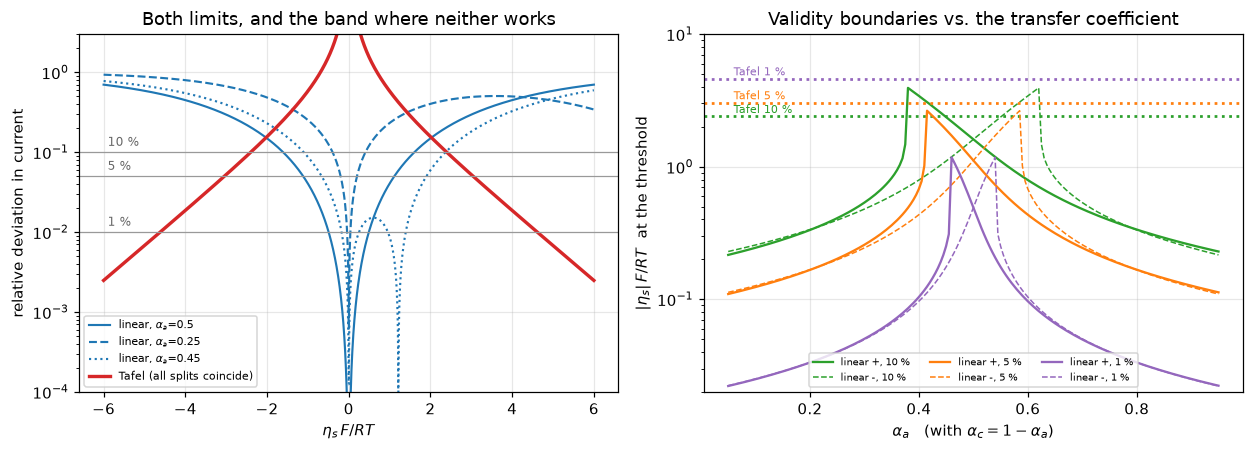

Left: the Tafel curve is drawn once because every split with alpha_a + alpha_c = 1 gives
exactly the same deviation. The linear curves do depend on the split, and the dotted
one (alpha_a = 0.45) shows the cancellation dip that produces the anomaly.
Right: Tafel boundaries (dotted) are horizontal lines - independent of the split.
The linear boundaries (solid = anodic, dashed = cathodic) fall away on both sides,
with the cancellation spike just off alpha_a = 0.5.


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

eh = np.linspace(-6.0, 6.0, 2400)                 # eta_s in units of RT/F
for aa, style in [(0.5, "-"), (0.25, "--"), (0.45, ":")]:
    ac = 1.0 - aa
    full = np.exp(aa * eh) - np.exp(-ac * eh)
    lin = (aa + ac) * eh
    ax[0].plot(eh, np.abs(lin / full - 1.0), "C0" + style, lw=1.4,
               label=rf"linear, $\alpha_a$={aa}")
# every alpha split with alpha_a + alpha_c = 1 gives the SAME Tafel deviation
taf_dev = np.abs(1.0 / np.expm1(np.abs(eh)))
ax[0].plot(eh, taf_dev, "C3-", lw=2.2, label="Tafel (all splits coincide)")
for eps in levels:
    ax[0].axhline(eps, color="0.6", lw=0.8)
    ax[0].text(-5.9, eps * 1.2, f"{100*eps:.0f} %", fontsize=8, color="0.4")
ax[0].set_yscale("log")
ax[0].set_ylim(1e-4, 3.0)
ax[0].set_xlabel(r"$\eta_s\,F/RT$")
ax[0].set_ylabel("relative deviation in current")
ax[0].set_title("Both limits, and the band where neither works")
ax[0].legend(fontsize=7, loc="lower left")

aa_grid = np.linspace(0.05, 0.95, 181)
for eps, col in zip(levels, ["C2", "C1", "C4"]):
    lin_hi = np.array([eta_linear_threshold(eps, a, 1 - a, +1) for a in aa_grid]) / RTF
    lin_lo = np.array([eta_linear_threshold(eps, a, 1 - a, -1) for a in aa_grid]) / RTF
    ax[1].plot(aa_grid, lin_hi, col + "-", lw=1.5, label=f"linear +, {100*eps:.0f} %")
    ax[1].plot(aa_grid, lin_lo, col + "--", lw=1.0, label=f"linear -, {100*eps:.0f} %")
    ax[1].axhline(eta_tafel_threshold(eps, 1.0) / RTF, color=col, ls=":", lw=1.8)
    ax[1].text(0.06, eta_tafel_threshold(eps, 1.0) / RTF * 1.06,
               f"Tafel {100*eps:.0f} %", fontsize=7, color=col)
ax[1].set_yscale("log")
ax[1].set_ylim(2e-2, 1e1)
ax[1].set_xlabel(r"$\alpha_a$   (with $\alpha_c = 1-\alpha_a$)")
ax[1].set_ylabel(r"$|\eta_s|\,F/RT$  at the threshold")
ax[1].set_title("Validity boundaries vs. the transfer coefficient")
ax[1].legend(fontsize=6.5, ncol=3, loc="lower center")
fig.tight_layout()
plt.show()

print("Left: the Tafel curve is drawn once because every split with "
      "alpha_a + alpha_c = 1 gives\nexactly the same deviation. The linear curves "
      "do depend on the split, and the dotted\none (alpha_a = 0.45) shows the "
      "cancellation dip that produces the anomaly.")
print("Right: Tafel boundaries (dotted) are horizontal lines - independent of the "
      "split.\nThe linear boundaries (solid = anodic, dashed = cathodic) fall away "
      "on both sides,\nwith the cancellation spike just off alpha_a = 0.5.")

## The published cell as an operating envelope

The thresholds above are properties of the equation. Whether they bite depends on
where a real electrode sits, and that is a reactor question. Below is `J3.4`'s
cell, ported with the kinetic law made selectable, run to extract the one thing
that page never reports: the distribution of $\eta_s$.

In [13]:
def kappa_from_delta(delta=None, I=10.0):
    """J3.4's reconstruction of the unprinted conductivity, from Doyle's Eq. 28."""
    delta = S["delta"] if delta is None else delta
    pre = alpha * F_CONST * I * dc / (R_GAS * T)
    return 1.0 / (delta / pre - 1.0 / sigma)


BRUG = eps_c ** 1.5
KAPPA = kappa_from_delta() / BRUG            # bulk value; kappa_eff = KAPPA * eps^1.5
print(f"kappa (bulk, reconstructed on J3.4) = {KAPPA:.4f} S/m")


class Cell:
    """The J3.4 DFN cell. Two changes: `kinetics` selects the law, and `march`
    carries J3.5's `dt_scale` (default 1.0 = the production schedule)."""

    def __init__(self, n_s=24, n_c=48, nu_factor=2.0, p_D=0.5, kinetics="eq17"):
        self.kinetics = kinetics
        self.eps_c, self.dc = eps_c, dc
        self.kappa, self.nu_factor = KAPPA, nu_factor
        N = n_s + n_c
        self.N, self.n_s = N, n_s
        # one grid, with a face exactly at x = delta_s
        x_f = np.concatenate([np.linspace(0.0, ds, n_s + 1),
                              np.linspace(ds, ds + self.dc, n_c + 1)[1:]])
        self.x_f, self.x_c = x_f, 0.5 * (x_f[:-1] + x_f[1:])
        self.dx = np.diff(x_f)

        sep = np.arange(N) < n_s
        self.eps = np.where(sep, 1.0, self.eps_c)              # separator is pure polymer
        self.a = np.where(sep, 0.0, 3.0 * (1 - self.eps_c) / P["R_s"])
        self.brug_k = self.eps ** 1.5                          # kappa_eff = kappa eps^1.5
        self.brug_D = self.eps ** p_D                          # D_eff = D eps^0.5 (J3.4)

        w = self.dx

        def to_face(b):                                        # harmonic mean; eps jumps
            bf = np.empty(N + 1)
            bf[1:-1] = (w[:-1] + w[1:]) / (w[:-1] / b[:-1] + w[1:] / b[1:])
            bf[0], bf[-1] = b[0], b[-1]
            return bf

        self.kf = self.kappa * to_face(self.brug_k)
        self.Df = P["D"] * to_face(self.brug_D)

        # outward normal, a dy/dn + b y = d; homogeneous Neumann at both ends, so the
        # operator returns zero on the boundary faces and the physical boundary fluxes
        # (i2 = I at the anode, i2 = 0 and N = 0 at the collector) are written there.
        bc = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
        self.grad, _ = construct_grad((N,), x_f, self.x_c, bc)
        self.div = construct_div((N,), x_f, nu=0)              # nu=0: Cartesian slab
        self.numjac = NumJac((N, 3), stencil=stencil_block_diagonals(
            ndims=2, axes_diagonals=[0], axes_blocks=[-1]))
        self.t_full = (1 - self.eps_c) * C_T * self.dc * F_CONST   # / I = discharge time

    @staticmethod
    def t0_plus(c):
        """Appendix A of Doyle et al.: transference number, linear in c."""
        return P["t0_a"] + P["t0_b"] * c

    def unpack(self, y):
        y = y.reshape(self.N, 3)
        c = P["c_0"] * np.exp(np.clip(y[:, 0], -40.0, 5.0))    # positivity is structural
        return c, y[:, 1] * RTF, y[:, 2] * C_T

    def fluxes(self, c, phi2, I):
        gc, glnc, gp = self.grad @ c, self.grad @ np.log(c), self.grad @ phi2
        t0f = np.empty(self.N + 1)
        t0f[1:-1] = 0.5 * (self.t0_plus(c[:-1]) + self.t0_plus(c[1:]))
        t0f[0], t0f[-1] = self.t0_plus(c[0]), self.t0_plus(c[-1])
        i2 = -self.kf * gp + self.nu_factor * self.kf * RTF * (1 - t0f) * glnc
        i2[0], i2[-1] = I, 0.0                     # Eq. 24 at the anode; Eq. 12 at the collector
        n_salt = -self.Df * gc - (1 - t0f) * i2 / F_CONST
        n_salt[0] = n_salt[-1] = 0.0               # no anion into the lithium; nothing through the collector
        return i2, n_salt

    def eta_surface(self, c, phi2, cs):
        """eta_s = eta - U_2, with Phi_1 gauged to zero so eta = -Phi_2."""
        css = np.clip(cs, 1.0, C_T - 1.0)
        return -phi2 - (U_prime(css) + RTF * np.log((C_T - css) / css))

    def i_transfer(self, c, phi2, cs):
        cc = np.clip(c, 1.0, C_MAX - 1.0)
        css = np.clip(cs, 1.0, C_T - 1.0)
        if self.kinetics == "eq17":
            z = np.clip(alpha * f_RT * (-phi2 - U_prime(css)), -200.0, 200.0)
            pre = F_CONST * P["k_2"] * (C_MAX - cc) ** alpha * cc ** alpha
            return pre * (css * np.exp(z) - (C_T - css) * np.exp(-z))
        i0 = i0_eq30(cc, css)
        eta_s = self.eta_surface(cc, phi2, css)
        if self.kinetics == "bv":
            z = np.clip(alpha * f_RT * eta_s, -200.0, 200.0)
            return i0 * (np.exp(z) - np.exp(-z))
        if self.kinetics == "linear":
            return i0 * 2.0 * alpha * f_RT * eta_s
        if self.kinetics == "tafel":            # cathodic branch, chosen a priori
            return -i0 * np.exp(np.clip(-alpha * f_RT * eta_s, -200.0, 200.0))
        raise ValueError(self.kinetics)

    def residual(self, y, y_old, dt, I):
        c, phi2, cs = self.unpack(y)
        c_o, _, cs_o = self.unpack(y_old)
        i2, n_salt = self.fluxes(c, phi2, I)
        ai = self.a * self.i_transfer(c, phi2, cs)
        r_c = self.eps * (c - c_o) / dt + self.div @ n_salt
        r_p = self.div @ i2 - ai
        r_s = np.where(self.a > 0,
                       (1 - self.eps_c) * (cs - cs_o) / dt + ai / F_CONST, cs)
        ts = self.t_full / abs(I)
        return np.stack([r_c * ts / P["c_0"], r_p * self.dc / abs(I),
                         r_s * ts / C_T], axis=1).ravel()

    def eta_anode(self, c0, I, law=None):
        """Doyle Eqs. 6-8 at the lithium foil, in whichever kinetic law."""
        law = self.kinetics if law is None else law
        i01 = P["i_0_1"] * np.sqrt((C_MAX - c0) * c0 / ((C_MAX - P["c_0"]) * P["c_0"]))
        if law in ("eq17", "bv"):
            return 2 * RTF * np.arcsinh(I / (2 * i01)), i01
        if law == "linear":
            return RTF * I / i01, i01
        if law == "tafel":                       # anodic branch, chosen a priori
            return 2 * RTF * np.log(np.maximum(I / i01, 1e-300)), i01
        raise ValueError(law)

    def cell_potential(self, y, I, anode_law=None):
        """Phi_1(collector) - Phi_1(anode), with Phi_1(anode) = 0."""
        c, phi2, _ = self.unpack(y)
        eta_s1, _ = self.eta_anode(c[0], I, anode_law)
        k0 = self.kappa * self.brug_k[0]
        dlnc = -(1 - self.t0_plus(c[0])) * I / (F_CONST * self.Df[0] * c[0])
        dphi = (-I + self.nu_factor * k0 * RTF * (1 - self.t0_plus(c[0])) * dlnc) / k0
        phi2_0 = phi2[0] - self.x_c[0] * dphi
        return -phi2_0 - eta_s1 - I * self.dc / (2 * sigma)                   # Eq. 22

    def utilisation(self, y):
        _, _, cs = self.unpack(y)
        m = self.a > 0
        return float(np.sum(cs[m] * self.dx[m]) / (C_T * self.dc))            # Eq. 25

    def salt(self, y):
        return float(np.sum(self.eps * self.dx * self.unpack(y)[0]))

    def initial(self, u0, I):
        """Uniform-current initial guess, consistent with the chosen law."""
        y = np.zeros((self.N, 3))
        i_avg = -I / (a_spec * self.dc)
        i0v = float(i0_eq30(P["c_0"], u0 * C_T))
        if self.kinetics in ("eq17", "bv"):
            e0 = RTF / alpha * np.arcsinh(i_avg / (2 * i0v))
        elif self.kinetics == "linear":
            e0 = RTF * i_avg / (2 * alpha * i0v)
        else:
            e0 = -RTF / alpha * np.log(max(-i_avg / i0v, 1e-300))
        y[:, 1] = -(U_ocp(u0) + e0) * f_RT
        y[:, 2] = u0
        return y

    def _step(self, y_old, dt, I):
        def fun(z):
            return self.numjac(lambda w: self.residual(w, y_old.ravel(), dt, I), z)
        try:
            sol = newton(fun, y_old.copy(), tol=1e-9, maxfev=30)
        except (ValueError, RuntimeError, np.linalg.LinAlgError):
            return None
        if not np.all(np.isfinite(sol.x)):
            return None
        r = self.residual(sol.x.ravel(), y_old.ravel(), dt, I)
        return sol.x if np.max(np.abs(r)) < 1e-6 else None

    def march(self, I, u0=None, v_stop=1.55, u_stop=0.9995, max_steps=2500,
              dt_seq=None, dt_scale=1.0):
        """Implicit-Euler march; dt halves on a failed Newton solve.

        `dt_seq` replays a step sequence recorded from another run, so two
        kinetic laws can be compared on an IDENTICAL time grid. Without it, the
        adaptive stepper takes slightly different steps and the difference
        between two runs is contaminated by time-discretisation error - which on
        this cell is larger than the effect being measured.

        `dt_scale` multiplies BOTH the initial step and the ceiling, so the whole
        schedule refines together; it is the only knob on this class that
        controls the temporal error at all. Scaling `dt` alone would do nothing:
        on a schedule that grows x1.3 per step the step reached at a given time
        is set by `dt_max`, not by the starting value. This is `J3.5`'s fix,
        which `J3.4` inherited on 2026-08-05 and this page did not until now.
        `dt_scale = 1` is the production schedule, so every number this page
        published before the fix is unchanged by it."""
        u0 = P["u_0"] if u0 is None else u0
        y = self.initial(u0, I)
        t_ref = self.t_full / abs(I)
        dt, dt_max = 2e-5 * t_ref * dt_scale, 6e-3 * t_ref * dt_scale
        t, out, dts, dt_peak = 0.0, [], [], dt
        n_max = max_steps if dt_seq is None else len(dt_seq)
        for k in range(n_max):
            step_dt = dt if dt_seq is None else dt_seq[k]
            y_new = None
            for _retry in range(8):
                y_new = self._step(y, step_dt, I)
                if y_new is not None:
                    break
                if dt_seq is not None:
                    break            # a prescribed sequence must not be altered
                step_dt *= 0.4
            if y_new is None:
                break
            y, t = y_new, t + step_dt
            dts.append(step_dt)
            if dt_seq is None:
                dt = min(step_dt * 1.3, dt_max)
                dt_peak = max(dt_peak, dt)
                if dt < 1e-3 * dt_peak:
                    break    # the step size has collapsed: the model is done
            c, phi2, cs = self.unpack(y)
            m = self.a > 0
            es = self.eta_surface(c, phi2, cs)[m]
            wm = self.dx[m] / self.dx[m].sum()
            # the anode ALWAYS uses the exact law here, so that `kinetics`
            # isolates the porous cathode; the anode substitution is explicit in
            # I and is done separately, and mixing the two silently makes the
            # cathode comparison read the anode's error instead.
            u, v = self.utilisation(y), self.cell_potential(y, I, anode_law="bv")
            out.append((u, v, t, self.salt(y), float(np.max(np.abs(es))),
                        float(np.sum(wm * es)), float(self.eta_anode(c[0], I)[0]),
                        float(np.sum(wm * np.abs(es)))))
            if dt_seq is None and ((I > 0 and v < v_stop) or u > u_stop or u < 1e-4):
                break
        return np.array(out), np.array(dts)


COLS = ["u", "V", "t", "salt", "max|eta_s|", "mean eta_s", "eta_s1", "mean|eta_s|"]
print("Cell class ready.")

kappa (bulk, reconstructed on J3.4) = 0.0485 S/m
Cell class ready.


### What the cell actually runs at

The exact law (`eq17`) is solved at the three currents of Doyle's Figure 2 that
reach the cutoff, and the surface overpotential is read out of the solution.

**Where the readout stops is part of the result.** `Cell.march` is `J3.4`'s and
halts at `v_stop = 1.55` V, 150 mV *below* the cutoff the paper states and the
parameter file carries ($V_{\text{cutoff}} = 1.7$ V) — that margin exists so the
stepper has somewhere to go, not because the cell is meant to be operated there.
Every envelope number below is therefore read at $V_{\text{cutoff}}$, which is
what `J3.4` does with the same runs, and the march endpoint is printed beside it
and labelled as the stepper artefact it is.

In [14]:
runs, dtseq = {}, {}
for I in (5.0, 10.0, 20.0):
    runs[I], dtseq[I] = Cell(kinetics="eq17").march(I)
    print(f"I = {I:4.0f} A/m2 : {len(runs[I]):4d} steps, "
          f"u_final = {runs[I][-1, 0]:.3f}, V_final = {runs[I][-1, 1]:.3f} V")


def u_at_V(run, level):
    """Utilisation at which the monotone-falling cell potential passes `level`."""
    u, v = np.asarray(run[:, 0], float), np.asarray(run[:, 1], float)
    return float(np.interp(-level, -v, u)) if v.min() < level else np.nan


# Read at the paper's own cutoff, which is a loaded parameter, not a typed one.
V_CUT = P["V_cutoff"]
U_CUT = {I: u_at_V(r, V_CUT) for I, r in runs.items()}

env = []
for I, r in runs.items():
    # the envelope ends at whichever comes first in utilisation: the start of
    # the transport-limited tail (u = 0.80) or the paper's cutoff. At I = 20 the
    # cutoff is the binding one, and a u < 0.80 mask alone would let the whole
    # post-cutoff tail into the maximum - which is the defect corrected here.
    c_end = r[:, 0] <= min(0.80, U_CUT[I])
    env.append({
        "I / A m-2": I,
        "i_loc/i_0 if uniform": (I / (a_spec * dc)) / i0_init,
        f"u at {V_CUT} V cutoff": U_CUT[I],
        "cathode mean |eta_s| / mV": 1e3 * r[c_end, 7].max(),
        "cathode peak |eta_s| / mV": 1e3 * r[c_end, 4].max(),
        "anode eta_s1 / mV": 1e3 * r[c_end, 6].max(),
        "cathode peak PAST the cutoff / mV": 1e3 * r[:, 4].max(),
        "march endpoint u (v_stop=1.55)": r[-1, 0],
    })
env_tab = pd.DataFrame(env)
print()
print(env_tab.to_string(index=False, float_format=lambda v: f"{v:12.4g}"))

ETA_CATH_10 = float(runs[10.0][runs[10.0][:, 0] < 0.80, 4].max())
ETA_CATH_MEAN_10 = float(runs[10.0][runs[10.0][:, 0] < 0.80, 7].max())
ETA_AN_10 = float(runs[10.0][runs[10.0][:, 0] < 0.80, 6].max())
ETA_AN_20 = float(runs[20.0][runs[20.0][:, 0] < 0.80, 6].max())
m20 = runs[20.0][:, 0] <= min(0.80, U_CUT[20.0])
ETA_CATH_20 = float(runs[20.0][m20, 4].max())
ETA_CATH_20_FULL = float(runs[20.0][:, 4].max())
U_END_20 = float(runs[20.0][-1, 0])
V_END_20 = float(runs[20.0][-1, 1])
U19_20 = u_at_V(runs[20.0], 1.9)
print()
print("The cathode PEAK sits in the first cell next to the separator, where the "
      "reaction crowds,\nand in the first TIME STEP. It is a boundary layer in both, "
      "it is converged in\nneither, and Validation quantifies each - together with "
      "the sustained value that\nthe cathode runs at once the initial transient has "
      "decayed, which is stable.\nThe cell-averaged value is not grid-sensitive, and "
      "all of them are reported.")

# Reconcile against the stated results loaded from J3.4, rather than restating
# the march endpoint: the CSV carries the paper's own number for this collapse.
print()
print(f"I = 20 A/m2, where the collapse is read:")
print(f"  V = 1.9 V crossing                 : u = {U19_20:.4f}   "
      f"(J3.4 reports 0.264 for the same curve)")
print(f"  V = {V_CUT} V, the paper's cutoff       : u = {U_CUT[20.0]:.4f}")
print(f"  march endpoint, V = {V_END_20:.3f} V       : u = {U_END_20:.4f}   "
      f"<- a v_stop artefact, not a published condition")
print(f"  Doyle p. 1529, loaded from the CSV : u_at_sharp_drop = "
      f"{S['u_at_sharp_drop']:.2f}  (\"about 30%\")")
print(f"  I = 10 A/m2 at the same cutoff     : u = {U_CUT[10.0]:.4f}   "
      f"(J3.4 reports 0.831; Doyle states 0.84)")

I =    5 A/m2 :  184 steps, u_final = 1.000, V_final = 1.549 V


I =   10 A/m2 :  163 steps, u_final = 0.871, V_final = 1.530 V


I =   20 A/m2 :   84 steps, u_final = 0.403, V_final = 1.473 V

   I / A m-2  i_loc/i_0 if uniform  u at 1.7 V cutoff  cathode mean |eta_s| / mV  cathode peak |eta_s| / mV  anode eta_s1 / mV  cathode peak PAST the cutoff / mV  march endpoint u (v_stop=1.55)
           5             0.0005005             0.9815                    0.01594                     0.3111              12.64                             0.6573                          0.9997
          10              0.001001             0.8312                    0.03182                     0.7383              24.81                             0.7383                          0.8709
          20              0.002002             0.3707                    0.06353                      1.679              46.63                              3.705                          0.4033

The cathode PEAK sits in the first cell next to the separator, where the reaction crowds,
and in the first TIME STEP. It is a boundary layer in both, it is con

### The result: the two electrodes of the same cell are three decades apart

This is the useful part, and it is not what a reader would guess from the fact
that both electrodes obey the same equation.

**State the tolerance first, because the verdict depends on it.** At $I=10$ both
electrodes are inside the *5 %* linear window — the cathode by three decades, the
foil by a factor of about 1.4. They are in genuinely *different* regimes only at
the 1 % tolerance, where the foil is already out, or at $I=20$, where the foil is
out at the 5 % level too. What does not depend on the tolerance is the
**separation**: nearly three decades in $|\eta_s|$ between the two electrodes of
one cell, at one instant, under one equation. The cell below prints each
electrode against both thresholds so the reader can apply their own.

**The porous cathode is three decades inside the 5 % linear window.** Its
interfacial area is $a\delta_c = 210$ m² per m² of separator, so the local current
density is $I/(a\delta_c)$ — 0.0476 A/m² at $I=10$, computed below under
"Superficial or interfacial?" — against an exchange current density of
47.57 A/m². The reaction is not uniform (Doyle's own $\nu=68$ says the ohmic drop
dominates, so it crowds towards the separator), and the solve measures the real
peak rather than assuming uniformity, but even the peak leaves
$|\eta_s| \ll RT/F$. Doyle says as much in words — $k_2$ was "set equal to a value
corresponding to a nearly reversible situation" — and this puts a number on it.

**The lithium foil is at the edge of it.** It is flat, so its current density is
the cell's, $I$, against $i_{o1}=12.6$ A/m². At $I=20$ it runs at 47 mV, which is
past the 5 % linear threshold and heading for the 10 % one.

So on the same cell, at the same instant: linearising the cathode kinetics leaves
the cell potential unchanged to $10^{-10}$ mV, and linearising the anode kinetics
costs 0.6 mV at $I=10$ and 4.2 mV at $I=20$. And **Tafel is wrong at both** —
catastrophically at the cathode, where $i\ll i_0$ is exactly the regime Tafel is
not for.

At $I=20$ the cell is transport-limited and collapses, and the cathode peak
overpotential rises as the electrolyte depletes and $i_0$ falls with it. That
collapse is read at Doyle's own 1.7 V cutoff — the cell below prints where it
lands and what the peak is there, together with the correction this page had to
make to those two numbers.

In [15]:
print("Cathode, at the peak |eta_s| the solve finds (I = 10 A/m2):")
print(f"  |eta_s|                     = {1e3*ETA_CATH_10:.4f} mV "
      f"= {ETA_CATH_10/RTF:.3e} x RT/F")
print(f"  linear-limit error there    = "
      f"{abs((2*alpha*f_RT*ETA_CATH_10)/np.sinh(alpha*f_RT*ETA_CATH_10)/2 - 1):.3e}")
print(f"  Tafel-limit error there     = "
      f"{1.0/np.expm1(f_RT*ETA_CATH_10):.4g}  (i.e. {100/np.expm1(f_RT*ETA_CATH_10):.0f} %)")
print()
print("Anode (Doyle Eqs. 6-8, i_o1 = 12.6 A/m2):")
an = []
for I in (5.0, 10.0, 20.0):
    c_ref = P["c_0"]
    i01 = P["i_0_1"]
    ex = 2 * RTF * np.arcsinh(I / (2 * i01))
    li = RTF * I / i01
    ta = 2 * RTF * np.log(I / i01)
    an.append({"I / A m-2": I, "I / i_o1": I / i01,
               "exact eta_s1 / mV": 1e3 * ex,
               "linear / mV": 1e3 * li, "linear error / mV": 1e3 * (li - ex),
               "Tafel / mV": 1e3 * ta, "Tafel error / mV": 1e3 * (ta - ex)})
an_tab = pd.DataFrame(an)
print(an_tab.to_string(index=False, float_format=lambda v: f"{v:10.3f}"))
LIN_ANODE_20 = float(an_tab.loc[an_tab["I / A m-2"] == 20.0,
                                "linear error / mV"].iloc[0])
TAF_ANODE_10 = float(an_tab.loc[an_tab["I / A m-2"] == 10.0,
                                "Tafel error / mV"].iloc[0])

# the verdict depends on the tolerance, so both are printed against both thresholds
print()
print("Where each electrode sits, against the linear thresholds (the verdict is "
      "tolerance-dependent):")
thr = {e: eta_linear_threshold(e, 0.5, 0.5) for e in (0.05, 0.01)}
FOIL_LIN_ERR = {}
for name, e_s in [("porous cathode, mean", ETA_CATH_MEAN_10),
                  ("porous cathode, peak", ETA_CATH_10),
                  ("lithium foil, I = 10", ETA_AN_10),
                  ("lithium foil, I = 20", ETA_AN_20)]:
    u = alpha * f_RT * e_s
    err = abs(u / np.sinh(u) - 1.0)
    FOIL_LIN_ERR[name] = err
    print(f"  {name:22s}: |eta_s| = {1e3*e_s:7.3f} mV = "
          f"{e_s/thr[0.05]:6.3f} x the 5 % threshold, {e_s/thr[0.01]:6.3f} x the 1 % one"
          f"   (linear error {100*err:.3g} %)")
ETA_SEP_DECADES = float(np.log10(ETA_AN_10 / ETA_CATH_MEAN_10))
ETA_SEP_DECADES_PEAK = float(np.log10(ETA_AN_10 / ETA_CATH_10))
print(f"  separation between the two electrodes at I = 10: "
      f"{ETA_SEP_DECADES:.2f} decades on the cell-averaged cathode value, "
      f"{ETA_SEP_DECADES_PEAK:.2f} on its peak")

# Stated as computed output rather than as typed prose, because the two numbers
# it replaces were typed and survived review for exactly that reason.
display(Markdown(f"""
**The $I=20$ collapse, read at the cutoff.** The cell reaches
$V={V_CUT}$ V — Doyle's stated cutoff, loaded from the `J3.4` parameter file — at
$u={U_CUT[20.0]:.4f}$, and crosses 1.9 V at $u={U19_20:.4f}$, which is `J3.4`'s
0.264 for the same curve. Doyle p. 1529 says the potential "drops sharply when
about 30 % of the cathode material is utilized", and
`u_at_sharp_drop = {S['u_at_sharp_drop']:.2f}` sits in the stated-results file
loaded at the top of this page. Inside that envelope the cathode peak
overpotential reaches **{1e3*ETA_CATH_20:.3f} mV**, still
{thr[0.01]/ETA_CATH_20:.1f} times inside the 1 % linear window and
{thr[0.05]/ETA_CATH_20:.1f} times inside the 5 % one.

**Correction.** An earlier version of this page reported
{1e3*ETA_CATH_20_FULL:.1f} mV at $u={U_END_20:.2f}$ and called it the largest
kinetic overpotential anywhere in these runs. Both numbers were taken at the
*march endpoint* — $u={U_END_20:.4f}$ at $V={V_END_20:.3f}$ V, which is where
`v_stop = 1.55` V stops the stepper, {1e3*(V_CUT-V_END_20):.0f} mV past the
published cutoff and outside the operating envelope this section is about. The
superlative was wrong independently of that: the lithium foil at $I=20$ runs at
{1e3*ETA_AN_20:.1f} mV, more than an order of magnitude above any cathode value
here, so no cathode number is the largest overpotential anywhere.
"""))

Cathode, at the peak |eta_s| the solve finds (I = 10 A/m2):
  |eta_s|                     = 0.7383 mV = 2.296e-02 x RT/F
  linear-limit error there    = 2.197e-05
  Tafel-limit error there     = 43.05  (i.e. 4305 %)

Anode (Doyle Eqs. 6-8, i_o1 = 12.6 A/m2):
 I / A m-2   I / i_o1  exact eta_s1 / mV  linear / mV  linear error / mV  Tafel / mV  Tafel error / mV
     5.000      0.397             12.677       12.760              0.082     -59.438           -72.115
    10.000      0.794             24.893       25.519              0.626     -14.863           -39.756
    20.000      1.587             46.798       51.039              4.241      29.713           -17.085

Where each electrode sits, against the linear thresholds (the verdict is tolerance-dependent):
  porous cathode, mean  : |eta_s| =   0.032 mV =  0.001 x the 5 % threshold,  0.002 x the 1 % one   (linear error 4.08e-06 %)
  porous cathode, peak  : |eta_s| =   0.738 mV =  0.021 x the 5 % threshold,  0.047 x the 1 % one   (linear


**The $I=20$ collapse, read at the cutoff.** The cell reaches
$V=1.7$ V — Doyle's stated cutoff, loaded from the `J3.4` parameter file — at
$u=0.3707$, and crosses 1.9 V at $u=0.2638$, which is `J3.4`'s
0.264 for the same curve. Doyle p. 1529 says the potential "drops sharply when
about 30 % of the cathode material is utilized", and
`u_at_sharp_drop = 0.30` sits in the stated-results file
loaded at the top of this page. Inside that envelope the cathode peak
overpotential reaches **1.679 mV**, still
9.4 times inside the 1 % linear window and
21.4 times inside the 5 % one.

**Correction.** An earlier version of this page reported
3.7 mV at $u=0.40$ and called it the largest
kinetic overpotential anywhere in these runs. Both numbers were taken at the
*march endpoint* — $u=0.4033$ at $V=1.473$ V, which is where
`v_stop = 1.55` V stops the stepper, 227 mV past the
published cutoff and outside the operating envelope this section is about. The
superlative was wrong independently of that: the lithium foil at $I=20$ runs at
46.6 mV, more than an order of magnitude above any cathode value
here, so no cathode number is the largest overpotential anywhere.


### Superficial or interfacial? The factor that decides the regime

The classification above uses the **interfacial** current density,
$I/(a\delta_c)$, and that is the physically correct one. It is worth putting a
number on what the distinction is worth here, because the dramatic version of the
warning — that ignoring $a\delta_c$ would put this cathode in the Tafel regime —
is false, and a reader who believed it would mis-diagnose their own cell in
exactly the direction the warning is meant to prevent.

In [16]:
print("Superficial vs interfacial current density, at Doyle's I = "
      f"{I_REF:.0f} A/m2 and i_0 = {i0_init:.2f} A/m2:")
i_sup, i_int = I_REF, I_REF / (a_spec * dc)
for name, i_loc in [("superficial I", i_sup), ("interfacial I/(a delta_c)", i_int)]:
    e_s = RTF / alpha * np.arcsinh(i_loc / (2 * i0_init))
    u = alpha * f_RT * e_s
    print(f"  {name:26s}: i = {i_loc:8.4f} A/m2, i/i_0 = {i_loc/i0_init:9.3e}, "
          f"eta_s = {1e3*e_s:8.4f} mV,\n"
          f"  {'':26s}  linear error {100*abs(u/np.sinh(u)-1):9.3g} %, "
          f"Tafel error {100/np.expm1(f_RT*e_s):9.3g} %")
print(f"  the factor between them is a delta_c = {a_spec*dc:.0f}")
print()
e_sup = RTF / alpha * np.arcsinh(i_sup / (2 * i0_init))
print(f"So even the SUPERFICIAL reading is inside the linear window: "
      f"{e_sup/thr[0.01]:.2f} x the 1 % threshold")
print(f"({1e3*thr[0.01]:.2f} mV) and {e_sup/thr[0.05]:.2f} x the 5 % one "
      f"({1e3*thr[0.05]:.2f} mV). It is not near Tafel:")
i_taf5 = 2 * i0_init * np.sinh(alpha * f_RT * eta_tafel_threshold(0.05))
print(f"the 5 % Tafel boundary sits at i/i_0 = {i_taf5/i0_init:.2f}, which is "
      f"{i_taf5/i_sup:.1f} x this cell's")
print("superficial current and " f"{i_taf5/i_int:.0f} x its interfacial one.")
print()
print("What a delta_c changes here is depth inside the linear window, not the "
      "regime:")
print(f"  linear error, superficial reading  = "
      f"{100*abs(alpha*f_RT*e_sup/np.sinh(alpha*f_RT*e_sup)-1):.3g} %")
e_int = RTF / alpha * np.arcsinh(i_int / (2 * i0_init))
print(f"  linear error, interfacial reading  = "
      f"{100*abs(alpha*f_RT*e_int/np.sinh(alpha*f_RT*e_int)-1):.3g} %")
print("Both are inside every tolerance on this page. The factor would decide the "
      "verdict only")
print(f"at about {i_taf5/i_sup:.0f} x this current, where the superficial reading "
      "reaches the Tafel boundary")
print("while the interface is still linear - which is exactly when getting it "
      "wrong costs something.")
A_DELTA_C = float(a_spec * dc)
SUP_LIN_ERR = float(abs(alpha * f_RT * e_sup / np.sinh(alpha * f_RT * e_sup) - 1.0))
INT_LIN_ERR = float(abs(alpha * f_RT * e_int / np.sinh(alpha * f_RT * e_int) - 1.0))
SUP_TAFEL_HEADROOM = float(i_taf5 / i_sup)

# the same ratio appears on J3.5 as C_r, on a different i_0 scale. Reconcile it here
# so the two pages are not read as disagreeing.
PRE0 = F_CONST * P["k_2"] * (C_MAX - P["c_0"]) ** alpha * P["c_0"] ** alpha
C_R_J35 = I_REF / (a_spec * PRE0 * C_T * dc)      # J3.5's C_r_doyle, verbatim
C_R_HERE = i_int / i0_init
I0_SCALE_RATIO = i0_init / (PRE0 * C_T)
print()
print("The same ratio on J3.5, and why the two pages print different numbers:")
print(f"  this page,  i/(a delta_c i_o2 from Eq. 30 at the initial state) = "
      f"{C_R_HERE:.3e}")
print(f"  J3.5 C_r,   i/(a delta_c * PRE0 * c_T)                          = "
      f"{C_R_J35:.3e}")
print(f"  ratio = {C_R_J35/C_R_HERE:.4f} = i_o2 / (PRE0 c_T) = "
      f"{I0_SCALE_RATIO:.4f} = sqrt(u_0 (1 - u_0)) = "
      f"{np.sqrt(P['u_0']*(1-P['u_0'])):.4f}")
print("J3.5 follows Marquis in scaling on a TYPICAL exchange current, with the solid")
print("concentration factors replaced by c_T; this page evaluates Eq. 30 at the state")
print(f"Doyle specifies, where the solid is only {100*P['u_0']:.0f} % lithiated. The two "
      "differ by exactly")
print("sqrt(u_0(1-u_0)) and are the same quantity. Neither is wrong; they are not "
      "comparable.")

Superficial vs interfacial current density, at Doyle's I = 10 A/m2 and i_0 = 47.57 A/m2:
  superficial I             : i =  10.0000 A/m2, i/i_0 = 2.102e-01, eta_s =   6.7463 mV,
                              linear error     0.183 %, Tafel error       428 %
  interfacial I/(a delta_c) : i =   0.0476 A/m2, i/i_0 = 1.001e-03, eta_s =   0.0322 mV,
                              linear error  4.17e-06 %, Tafel error  9.99e+04 %
  the factor between them is a delta_c = 210

So even the SUPERFICIAL reading is inside the linear window: 0.43 x the 1 % threshold
(15.81 mV) and 0.19 x the 5 % one (35.86 mV). It is not near Tafel:
the 5 % Tafel boundary sits at i/i_0 = 4.36, which is 20.8 x this cell's
superficial current and 4360 x its interfacial one.

What a delta_c changes here is depth inside the linear window, not the regime:
  linear error, superficial reading  = 0.183 %
  linear error, interfacial reading  = 4.17e-06 %
Both are inside every tolerance on this page. The factor would decide t

### Substituting the limit into the reactor, and paying for it

The pointwise error is not the number an engineer needs; the number they need is
what it does to the cell. So the same cell is re-solved with the limit laws in
place of Eq. 17, and the cell potential is compared. The cathode substitution
changes the field equations and needs a full re-solve; the anode substitution is
explicit, so all three anode variants come from one solve.

Two things had to be got right before this comparison meant anything, and both
were wrong in the first version of this page.

* **The two runs must step in time identically.** With independent adaptive
  stepping the linear and exact runs differ by 0.44 mV — which is
  time-discretisation error, not kinetics. The reference run's step sequence is
  recorded and replayed, so the comparison is step-for-step with no
  interpolation.
* **Only one electrode may be substituted at a time.** The cell potential
  contains the anode overpotential, so a `Cell` that switches both laws at once
  reports the anode's error as the cathode's. Here the anode always uses the
  exact law and the switch acts on the porous cathode alone.

With both fixed, the linear-cathode deviation drops from a plausible-looking
0.44 mV to $1.5\times10^{-10}$ mV. The first number was not a small error; it was
a measurement of the wrong thing.

The Tafel-substituted cathode is worth predicting before running it. Tafel with
$i\ll i_0$ has no solution near $\eta_s=0$: the single exponential must be driven
down to $i/i_0\approx10^{-3}$, which needs
$\eta_s = \frac{RT}{\alpha_cF}\ln(i_0/|i|) \approx +444$ mV of the *wrong sign*.
The approximation does not merely lose accuracy — it reverses the sign of the
polarisation.

In [17]:
pred_tafel = RTF / alpha * np.log(i0_init / (I_REF / (a_spec * dc)))
print(f"predicted Tafel cathode overpotential at I = 10 : {1e3*pred_tafel:+.1f} mV")

ref = runs[I_REF]
seq = dtseq[I_REF]           # replay the reference step sequence exactly

sub = {}
for law in ("bv", "linear", "tafel"):
    sub[law], _ = Cell(kinetics=law).march(I_REF, dt_seq=seq)
    print(f"  {law:7s}: {len(sub[law]):4d} steps (reference: {len(ref)}), "
          f"cathode mean eta_s at step 0 = {1e3*sub[law][0, 5]:+9.3f} mV, "
          f"V = {sub[law][0, 1]:.4f} V")

TAFEL_PRED_DEV = float(abs(sub["tafel"][0, 5] / pred_tafel - 1.0))
print(f"\n  -> the Tafel run's first-step overpotential matches the "
      f"uniform-reaction prediction to {100*TAFEL_PRED_DEV:.2f} %")


def dv(law, lo=0.10, hi=0.70):
    """Cell-potential difference at IDENTICAL time steps (no interpolation)."""
    n = min(len(ref), len(sub[law]))
    m = (ref[:n, 0] > lo) & (ref[:n, 0] < hi)
    return float(np.max(np.abs(sub[law][:n, 1][m] - ref[:n, 1][m])))


BV_VS_EQ17, LIN_CATH_DV, TAF_CATH_DV = dv("bv"), dv("linear"), dv("tafel")
print()
print(f"cell potential, max |deviation| over u = 0.10-0.70 at I = {I_REF:.0f} A/m2,")
print("compared step-for-step on the same time grid:")
print(f"  standard form (Eq. 30 + Eq. 6) vs Eq. 17 as printed : "
      f"{1e3*BV_VS_EQ17:.3e} mV   <- must be zero")
print(f"  linear cathode kinetics                             : "
      f"{1e3*LIN_CATH_DV:.3e} mV")
print(f"  Tafel  cathode kinetics                             : "
      f"{1e3*TAF_CATH_DV:9.1f} mV")

# the anode substitution is explicit in I, so it needs no re-solve
print()
print("anode substitution, cell potential shift at I = 10 and 20 A/m2:")
AN_SHIFT = {}
for I in (10.0, 20.0):
    i01 = P["i_0_1"]
    ex = 2 * RTF * np.arcsinh(I / (2 * i01))
    for law, val in [("linear", RTF * I / i01), ("tafel", 2 * RTF * np.log(I / i01))]:
        AN_SHIFT[(I, law)] = -(val - ex)     # V = ... - eta_s1, so dV = -d(eta_s1)
        print(f"  I = {I:4.0f}, {law:7s}: dV = {1e3*AN_SHIFT[(I, law)]:+9.2f} mV")

predicted Tafel cathode overpotential at I = 10 : +444.2 mV


  bv     :  163 steps (reference: 163), cathode mean eta_s at step 0 =    -0.032 mV, V = 2.5323 V


  linear :  162 steps (reference: 163), cathode mean eta_s at step 0 =    -0.032 mV, V = 2.5323 V


  tafel  :  160 steps (reference: 163), cathode mean eta_s at step 0 =  +446.220 mV, V = 2.9458 V

  -> the Tafel run's first-step overpotential matches the uniform-reaction prediction to 0.46 %

cell potential, max |deviation| over u = 0.10-0.70 at I = 10 A/m2,
compared step-for-step on the same time grid:
  standard form (Eq. 30 + Eq. 6) vs Eq. 17 as printed : 2.220e-12 mV   <- must be zero
  linear cathode kinetics                             : 1.452e-10 mV
  Tafel  cathode kinetics                             :     519.1 mV

anode substitution, cell potential shift at I = 10 and 20 A/m2:
  I =   10, linear : dV =     -0.63 mV
  I =   10, tafel  : dV =    +39.76 mV
  I =   20, linear : dV =     -4.24 mV
  I =   20, tafel  : dV =    +17.08 mV


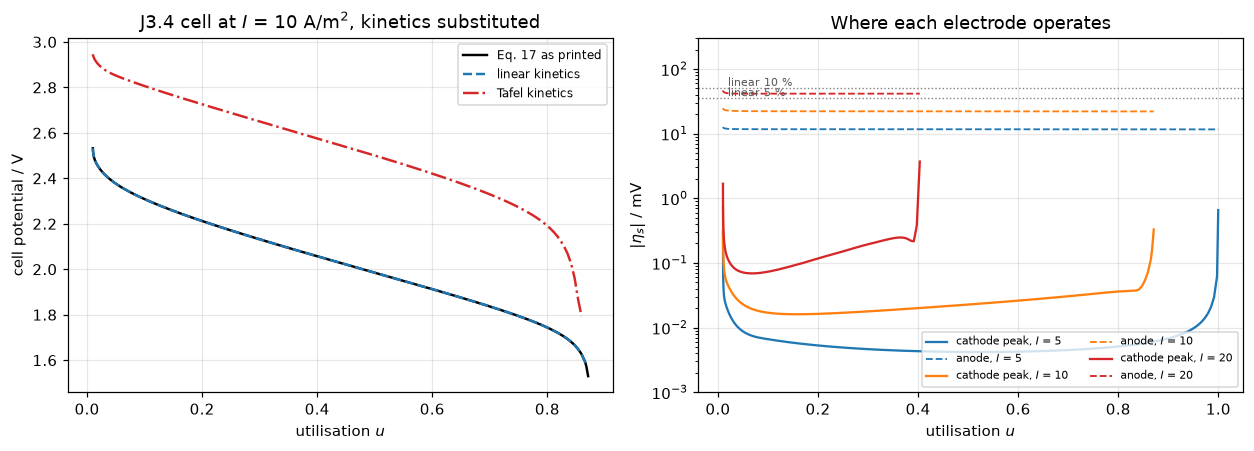

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

for law, lab, st in [("eq17", "Eq. 17 as printed", "k-"),
                     ("linear", "linear kinetics", "C0--"),
                     ("tafel", "Tafel kinetics", "C3-.")]:
    r = ref if law == "eq17" else sub[law]
    ax[0].plot(r[:, 0], r[:, 1], st, lw=1.6, label=lab)
ax[0].set_xlabel("utilisation $u$")
ax[0].set_ylabel("cell potential / V")
ax[0].set_title(f"J3.4 cell at $I$ = {I_REF:.0f} A/m$^2$, kinetics substituted")
ax[0].legend(fontsize=8)

for I, col in zip((5.0, 10.0, 20.0), ["C0", "C1", "C3"]):
    r = runs[I]
    ax[1].plot(r[:, 0], 1e3 * r[:, 4], col + "-", lw=1.5,
               label=f"cathode peak, $I$ = {I:.0f}")
    ax[1].plot(r[:, 0], 1e3 * r[:, 6], col + "--", lw=1.2,
               label=f"anode, $I$ = {I:.0f}")
for eps, lab in [(0.05, "5 %"), (0.10, "10 %")]:
    thr = 1e3 * eta_linear_threshold(eps, 0.5, 0.5, +1)
    ax[1].axhline(thr, color="0.5", lw=0.9, ls=":")
    ax[1].text(0.02, thr * 1.06, f"linear {lab}", fontsize=7, color="0.35")
ax[1].set_yscale("log")
ax[1].set_ylim(1e-3, 3e2)
ax[1].set_xlabel("utilisation $u$")
ax[1].set_ylabel(r"$|\eta_s|$ / mV")
ax[1].set_title("Where each electrode operates")
ax[1].legend(fontsize=7, ncol=2, loc="lower right")
fig.tight_layout()
plt.show()

## Validation

Ranked before any code was written, and taken in order.

**(2) Internal identities.** The strongest route available, because this is a
constitutive law and the paper prints three equations that must be consistent.
Eq. 17 (page 1528), Eq. 16 (page 1528) and Eq. 30 (page 1530) are printed
separately and not derived from one another; reducing Eq. 17 with Eq. 16
reproduces Eq. 30 exactly, and the reduction is only possible when
$\alpha_a+\alpha_c=1$. Four further structural identities are checked above.

**(3) A stated numerical result.** Doyle prints $\delta=1.95$ and $\nu=68$. Their
ratio eliminates the conductivity — the one input the paper never gives — and
becomes a direct test of Eq. 30's exchange current density.

**(4) A digitised figure.** Not used, and not needed. Nothing was digitised for
this page.

Two additional checks below: the ported cell must be insensitive to the grid, and
its salt balance must close exactly, since the flux form makes conservation a
property of the discretisation rather than of the solve. Both inherited from
`J3.4`, both re-run here because the kinetic switch touches the residual.

**And a third, which should have been here from the start.** `Cell.march` sets
`dt` and `dt_max` from the current alone — they are functions of $I$ and the
reference discharge time and of *neither* $n_s$ nor $n_c$. So the grid ladder
below refines space at a **constant temporal error**, and the three `grid_*`
numbers this page publishes measure one component of the discretisation error
while reading as though they measured it. `J3.5` fixed exactly this in the same
shared helper, by adding a `dt_scale` that multiplies `dt` *and* `dt_max`;
`J3.4` took the fix on 2026-08-05; this page did not inherit it until now.
`dt_scale = 1` is the production schedule, so nothing already published moves —
and the measurement that was missing is below. It is the **larger** of the two
errors.

The salt balance gets the break row it never had at the same time: a conservation
residual that is exact by construction is not evidence until something is shown
to move it, and the only thing that can is a salt-flux boundary condition.

**Three defects were found by these checks and none by reading the code.** They
are recorded because each is a way this page could have looked right and been
wrong:

1. A bracketing root-find on the linear deviation returned a *later* crossing,
   reporting the $\alpha_a=0.3$ threshold as 203 mV instead of 8.3 mV.
2. Comparing two kinetic laws through independently adaptive time stepping put
   0.44 mV of time-discretisation error into a quantity whose true value is
   $10^{-10}$ mV.
3. Switching the kinetic law switched it at *both* electrodes, so the "cathode"
   comparison was reading the anode's error — and the contaminated number,
   0.44 mV, happened to be almost identical to the one in (2). Two different
   defects, the same plausible-looking answer.

One number below is deliberately reported as **not converged**: the peak
$|\eta_s|$. It sits in the first cathode cell, where the reaction crowds against
the separator, and it still grows under refinement. Its successive increments do
shrink, so the sequence is converging — it has simply not arrived, and nothing
here claims it has.

Two things about that number are new on this version of the page, and both follow
from being able to refine time at all. **The peak sits in the very first time
step** — the cell prints the step index and the time, and it is a few tenths of a
second out of a discharge of hours. It is therefore a boundary layer in $t$ as
much as in $x$, it grows under *both* refinements, and a grid ladder at fixed
`dt` was never going to bound it. So the margin argument is re-made at the corner
where **both** knobs are refined together, not at the grid-refined one. And the
*sustained* peak — the largest $|\eta_s|$ once that initial transient has decayed
— is printed beside it, because that one is stable across the whole refinement
box and is the number a reader should carry away.

In [19]:
def v_at(run, u):
    """Cell potential interpolated at a given utilisation."""
    return float(np.interp(u, run[:, 0], run[:, 1]))


gr = {}
for n_s, n_c in [(12, 24), (24, 48), (48, 96), (96, 192)]:
    r, _ = Cell(n_s=n_s, n_c=n_c, kinetics="eq17").march(I_REF)
    gr[(n_s, n_c)] = r
    print(f"grid {n_s:3d}+{n_c:3d}: V at u=0.5 = {v_at(r, 0.5):.6f} V, "
          f"mean|eta_s| = {1e3*r[r[:, 0] < 0.8, 7].max():.5f} mV, "
          f"peak|eta_s| = {1e3*r[r[:, 0] < 0.8, 4].max():.5f} mV, "
          f"salt drift = {abs(r[:, 3].max()/r[:, 3].min() - 1):.2e}")

vs = [v_at(r, 0.5) for r in gr.values()]
em = [1e3 * r[r[:, 0] < 0.8, 7].max() for r in gr.values()]
ep = [1e3 * r[r[:, 0] < 0.8, 4].max() for r in gr.values()]
GRID_V = float(max(vs) - min(vs))
GRID_ETA_MEAN = float((max(em) - min(em)) / np.mean(em))
GRID_ETA_PEAK = float(max(ep) / min(ep))
SALT = float(max(abs(r[:, 3].max() / r[:, 3].min() - 1) for r in gr.values()))
print(f"\ncell potential spread over an 8x refinement  : {1e3*GRID_V:.3f} mV")
print(f"cell-averaged |eta_s| spread, 8x refinement  : {100*GRID_ETA_MEAN:.2f} %")
print(f"peak |eta_s|, ratio finest/coarsest          : {GRID_ETA_PEAK:.2f} x")
print(f"total salt conserved to                      : {SALT:.2e}")
print()
print("The peak is a boundary-layer value in the first cathode cell and is NOT "
      "converged at\nthese grids. Its successive increments are "
      + ", ".join(f"{d:.3f}" for d in np.diff(ep)) + " mV, i.e. the sequence")
print("is converging but has not arrived; nothing is concluded from it alone.")
THR_1PCT = float(1e3 * eta_linear_threshold(0.01, 0.5, 0.5))
print(f"  finest-grid peak |eta_s|          = {max(ep):.4f} mV")
print(f"  1 % linear-limit threshold        = {THR_1PCT:.2f} mV")
print(f"  margin on THIS ladder alone       = {THR_1PCT/max(ep):.1f} x, against "
      f"{GRID_ETA_PEAK:.2f} x of grid movement")
print()
print("ALL THREE of these spreads are SPATIAL ONLY. march() sets dt and dt_max from")
print("the current alone, so every row above was computed at the same temporal")
print("error, and none of the three says anything about it. The next cell measures")
print("it, and the margin quoted here is re-made there under both knobs at once.")

grid  12+ 24: V at u=0.5 = 1.984891 V, mean|eta_s| = 0.03190 mV, peak|eta_s| = 0.53017 mV, salt drift = 8.88e-16


grid  24+ 48: V at u=0.5 = 1.984998 V, mean|eta_s| = 0.03182 mV, peak|eta_s| = 0.73832 mV, salt drift = 4.44e-16


grid  48+ 96: V at u=0.5 = 1.985030 V, mean|eta_s| = 0.03178 mV, peak|eta_s| = 0.90391 mV, salt drift = 4.44e-16


grid  96+192: V at u=0.5 = 1.985040 V, mean|eta_s| = 0.03177 mV, peak|eta_s| = 1.00763 mV, salt drift = 4.44e-16

cell potential spread over an 8x refinement  : 0.149 mV
cell-averaged |eta_s| spread, 8x refinement  : 0.40 %
peak |eta_s|, ratio finest/coarsest          : 1.90 x
total salt conserved to                      : 8.88e-16

The peak is a boundary-layer value in the first cathode cell and is NOT converged at
these grids. Its successive increments are 0.208, 0.166, 0.104 mV, i.e. the sequence
is converging but has not arrived; nothing is concluded from it alone.
  finest-grid peak |eta_s|          = 1.0076 mV
  1 % linear-limit threshold        = 15.81 mV
  margin on THIS ladder alone       = 15.7 x, against 1.90 x of grid movement

ALL THREE of these spreads are SPATIAL ONLY. march() sets dt and dt_max from
the current alone, so every row above was computed at the same temporal
error, and none of the three says anything about it. The next cell measures
it, and the margin quoted

In [20]:
# ---- the knob the ladder above holds fixed ----------------------------------
# march() sets dt = 2e-5 t_ref and dt_max = 6e-3 t_ref, with t_ref = t_full/|I|.
# Neither depends on n_s or n_c. dt_scale multiplies BOTH, which is the only way
# to refine a schedule that grows x1.3 per step: scaling the initial step alone
# leaves dt_max, and so the step actually taken over almost the whole discharge,
# exactly where it was.
DT_LEVELS = ((1.0, 2500), (0.5, 2500), (0.25, 3000), (0.125, 5000))
dtr = {dts: Cell(kinetics="eq17").march(I_REF, dt_scale=dts, max_steps=ms)[0]
       for dts, ms in DT_LEVELS}
dv_ = [v_at(dtr[d], 0.5) for d, _ in DT_LEVELS]
dm_ = [1e3 * dtr[d][dtr[d][:, 0] < 0.8, 7].max() for d, _ in DT_LEVELS]
dp_ = [1e3 * dtr[d][dtr[d][:, 0] < 0.8, 4].max() for d, _ in DT_LEVELS]
ddif = [1e3 * abs(dv_[i + 1] - dv_[i]) for i in range(len(dv_) - 1)]

print("Time-step refinement at the production grid, I = 10 A/m2")
print(f"{'dt_scale':>9}{'steps':>7}{'V(u=0.5)/V':>13}{'change/mV':>11}{'order':>7}"
      f"{'mean|eta_s|/mV':>16}{'peak|eta_s|/mV':>16}")
for k, (dts, _) in enumerate(DT_LEVELS):
    chg = f"{ddif[k-1]:11.4f}" if k else " " * 11
    order = f"{np.log2(ddif[k-2]/ddif[k-1]):7.2f}" if k >= 2 else " " * 7
    print(f"{dts:9.4f}{len(dtr[dts]):7d}{dv_[k]:13.6f}{chg}{order}"
          f"{dm_[k]:16.5f}{dp_[k]:16.5f}")

DT_ORDER = float(np.mean([np.log2(ddif[i] / ddif[i + 1]) for i in range(len(ddif) - 1)]))
DT_V = float(max(dv_) - min(dv_))
DT_ETA_MEAN = float((max(dm_) - min(dm_)) / np.mean(dm_))
DT_ETA_PEAK = float(max(dp_) / min(dp_))
v_rich = dv_[-1] - (dv_[-2] - dv_[-1])              # first-order Richardson
DT_V_ERR = float(abs(dv_[0] - v_rich))
print(f"\nobserved order {DT_ORDER:.2f} - first order, which is what implicit Euler")
print("gives, so the extrapolation below is the right one to use.")
print(f"Richardson-extrapolated temporal error at the production dt_scale = 1 : "
      f"{1e3*DT_V_ERR:.3f} mV")
print()
print("The same three quantities under each knob, like for like:")
print(f"{'':34}{'8x grid':>11}{'8x dt':>11}{'dt / grid':>12}")
print(f"{'cell potential spread / mV':34}{1e3*GRID_V:11.4f}{1e3*DT_V:11.4f}"
      f"{DT_V/GRID_V:12.2f}")
print(f"{'cell-averaged |eta_s| spread / %':34}{100*GRID_ETA_MEAN:11.3f}"
      f"{100*DT_ETA_MEAN:11.3f}{DT_ETA_MEAN/GRID_ETA_MEAN:12.2f}")
print(f"{'peak |eta_s|, coarsest -> finest':34}{GRID_ETA_PEAK:11.3f}{DT_ETA_PEAK:11.3f}"
      f"{'see below':>12}")
print()
print(f"So on the cell potential the temporal error is {DT_V_ERR/GRID_V:.1f}x the grid "
      f"spread once it is\nextrapolated, and {DT_V/GRID_V:.1f}x it measured the same "
      "way; on the cell-averaged")
print(f"overpotential it is {DT_ETA_MEAN/GRID_ETA_MEAN:.1f}x. On both quantities that "
      "converge, the larger of")
print("the two numerical errors is the one that had never been measured. The peak is")
print("the exception and is not converged in either knob; it is taken apart below.")
print("J3.4 - the same cell, the same schedule - reports 0.273 mV against a 0.138 mV")
print("grid spread, which is consistent with this, as it must be: the two pages share")
print("the helper, and both numbers were missing for the same reason.")
print()
print("Nothing published moves. Every number on this page is taken at dt_scale = 1,")
print("and the argument they support - both electrodes deep inside the linear window,")
print("2.9 decades apart - has room of two orders of magnitude, not two tenths of a")
print("millivolt. What changes is that the three grid_* metrics are now labelled as")
print("the spatial half of a two-part error, with the other half measured beside them.")

Time-step refinement at the production grid, I = 10 A/m2
 dt_scale  steps   V(u=0.5)/V  change/mV  order  mean|eta_s|/mV  peak|eta_s|/mV
   1.0000    163     1.984998                           0.03182         0.73832
   0.5000    305     1.984865     0.1326                0.03197         0.84500
   0.2500    592     1.984796     0.0694   0.93         0.03207         0.92996
   0.1250   1164     1.984760     0.0357   0.96         0.03212         0.99226

observed order 0.95 - first order, which is what implicit Euler
gives, so the extrapolation below is the right one to use.
Richardson-extrapolated temporal error at the production dt_scale = 1 : 0.273 mV

The same three quantities under each knob, like for like:
                                      8x grid      8x dt   dt / grid
cell potential spread / mV             0.1488     0.2377        1.60
cell-averaged |eta_s| spread / %        0.403      0.949        2.35
peak |eta_s|, coarsest -> finest        1.901      1.344   see below

So

#### The peak overpotential is a *first-step* quantity

The one number the two ladders disagree about is the peak. The cell below says
where it actually sits, refines both knobs together, and separates the initial
spike from the value the cathode runs at for the rest of the discharge.

In [21]:
prod = gr[(24, 48)]                  # the production run: default grid, dt_scale = 1
mprod = prod[:, 0] < 0.8
kpk = int(np.argmax(prod[mprod, 4]))
print("Where the peak |eta_s| sits in the I = 10 A/m2 discharge:")
print(f"  step {kpk} of {int(mprod.sum())} inside the envelope, "
      f"t = {prod[kpk, 2]:.4g} s of {prod[-1, 2]:.4g} s "
      f"({prod[kpk, 2]/prod[-1, 2]:.1e} of the run), u = {prod[kpk, 0]:.5f}")
print("  -> it is the FIRST time step. The peak is the initial transient at the")
print("     separator face, and it is resolved by dt as much as by dx. That is why")
print("     it moves under both knobs and is converged under neither.")
print()

# the two knobs together, at the corner of the refinement box
CORNER = Cell(n_s=96, n_c=192, kinetics="eq17").march(I_REF, dt_scale=0.125,
                                                      max_steps=5000)[0]
mcor = CORNER[:, 0] < 0.8
CORNER_PEAK = float(1e3 * CORNER[mcor, 4].max())
PROD_PEAK = float(1e3 * prod[mprod, 4].max())
print(f"{'peak |eta_s| / mV':38}{'value':>10}{'margin to the 1 % threshold':>30}")
for lab, val in [("production grid, production dt", PROD_PEAK),
                 ("8x grid, production dt", max(ep)),
                 ("production grid, 8x dt", dp_[-1]),
                 ("8x grid AND 8x dt together", CORNER_PEAK)]:
    print(f"{lab:38}{val:10.4f}{THR_1PCT/val:30.1f}")
CORNER_MARGIN = float(THR_1PCT / CORNER_PEAK)
print(f"  (1 % linear-limit threshold = {THR_1PCT:.3f} mV)")
print()
print(f"Refining both knobs together moves the peak by a factor "
      f"{CORNER_PEAK/PROD_PEAK:.2f} from the")
print(f"published value and takes the margin from {THR_1PCT/PROD_PEAK:.1f}x to "
      f"{CORNER_MARGIN:.1f}x. It is still an order of")
print("magnitude, so the classification of the cathode as deep inside the linear")
print("window survives - but the honest margin is the smaller one, and the number")
print("quoted in the caveats is now this one.")
print()

# the sustained value: what the cathode runs at once the initial spike has gone
SUS_CUT = 10.0                       # s
def sustained(r):
    """Largest |eta_s| inside the envelope after the first-step transient."""
    m = (r[:, 0] < 0.8) & (r[:, 2] > SUS_CUT)
    return float(1e3 * r[m, 4].max())


sus = ([sustained(r) for r in gr.values()] + [sustained(dtr[d]) for d, _ in DT_LEVELS]
       + [sustained(CORNER)])
SUS_PEAK = sustained(prod)
SUS_SPREAD = float((max(sus) - min(sus)) / np.mean(sus))
print(f"Sustained peak |eta_s| (t > {SUS_CUT:.0f} s, i.e. past the first-step spike):")
print(f"  at the production point                    : {SUS_PEAK:.4f} mV")
print(f"  over all {len(sus)} runs in the refinement box    : "
      f"{min(sus):.4f} to {max(sus):.4f} mV, spread {100*SUS_SPREAD:.1f} %")
print(f"  margin to the 1 % threshold                : {THR_1PCT/max(sus):.0f} x")
print(f"That is {100*SUS_SPREAD:.1f} % of movement over the whole refinement box, "
      f"against a factor {CORNER_PEAK/PROD_PEAK:.2f}")
print("for the spike, so it is the number to carry away. The first-step spike is")
print(f"real, but it is a transient of the initial condition: {PROD_PEAK/SUS_PEAK:.1f}x "
      f"the sustained\nvalue at the production point and {CORNER_PEAK/max(sus):.1f}x it "
      "at the corner, and resolved by neither knob.")

Where the peak |eta_s| sits in the I = 10 A/m2 discharge:
  step 0 of 150 inside the envelope, t = 0.3917 s of 1.686e+04 s (2.3e-05 of the run), u = 0.01002
  -> it is the FIRST time step. The peak is the initial transient at the
     separator face, and it is resolved by dt as much as by dx. That is why
     it moves under both knobs and is converged under neither.



peak |eta_s| / mV                          value   margin to the 1 % threshold
production grid, production dt            0.7383                          21.4
8x grid, production dt                    1.0076                          15.7
production grid, 8x dt                    0.9923                          15.9
8x grid AND 8x dt together                1.5187                          10.4
  (1 % linear-limit threshold = 15.808 mV)

Refining both knobs together moves the peak by a factor 2.06 from the
published value and takes the margin from 21.4x to 10.4x. It is still an order of
magnitude, so the classification of the cathode as deep inside the linear
window survives - but the honest margin is the smaller one, and the number
quoted in the caveats is now this one.

Sustained peak |eta_s| (t > 10 s, i.e. past the first-step spike):
  at the production point                    : 0.1459 mV
  over all 9 runs in the refinement box    : 0.1427 to 0.1585 mV, spread 10.6 %
  margin to the 

#### The break row salt conservation never had

`salt_conservation` is a telescoping identity: with `n_salt[0] = n_salt[-1] = 0`
the discrete divergence sums to `n[N] - n[0] = 0` for **any** interior flux
expression and any parameters, so the residual is exact by construction. `J3.4`
says the same about its own copy. The one error class it *can* see is a wrong
salt-flux boundary condition, and until now nothing on this page measured that.
One line of the flux routine is changed below and nothing else.

In [22]:
class LeakyCell(Cell):
    """The same cell with ONE thing broken: the collector no longer holds N = 0."""

    LEAK = 0.0                       # published value: exactly zero (Eq. 12)

    def fluxes(self, c, phi2, I):
        i2, n_salt = super().fluxes(c, phi2, I)
        n_salt[-1] = self.LEAK * abs(I) / F_CONST
        return i2, n_salt


print("Salt conservation against a leaking collector boundary condition:")
print(f"{'n_salt[-1] as a fraction of I/F':34}{'steps':>7}{'salt drift':>13}"
      f"{'V(u=0.5)/V':>13}")
salt_break, leak_v = {}, {}
for leak in (0.0, 1e-3, 1e-2):
    LeakyCell.LEAK = leak
    rl, _ = LeakyCell(kinetics="eq17").march(I_REF)
    salt_break[leak] = float(abs(rl[:, 3].max() / rl[:, 3].min() - 1.0))
    leak_v[leak] = v_at(rl, 0.5)
    print(f"{leak:34.0e}{len(rl):7d}{salt_break[leak]:13.3e}{leak_v[leak]:13.6f}")
LeakyCell.LEAK = 0.0
SALT_BREAK = float(salt_break[1e-3])
print(f"\nSo it does have exactly one power: a 0.1 % leak at the collector takes it")
print(f"from {salt_break[0.0]:.2e} to {SALT_BREAK:.2e}, a factor of "
      f"{SALT_BREAK/max(salt_break[0.0], 1e-18):.1e}, and moves the")
print(f"cell potential by {1e3*abs(leak_v[1e-3] - leak_v[0.0]):.2f} mV - which is more "
      "than the whole numerical error budget")
print("measured above, so this is an error class worth being able to see. Reported as")
print("the identity it is, now with the row that says what the identity is worth.")
print()
print("Note also that the published residual sits below check_agreement.py's")
print("ABS_FLOOR = 1e-12, so CI has never compared it at all. The break row does not,")
print("so the evidence is CI-visible even where the residual it guards is not.")

Salt conservation against a leaking collector boundary condition:
n_salt[-1] as a fraction of I/F     steps   salt drift   V(u=0.5)/V


                             0e+00    163    4.441e-16     1.984998


                             1e-03    161    2.196e-02     1.981540


                             1e-02    143    2.291e-01     1.943877

So it does have exactly one power: a 0.1 % leak at the collector takes it
from 4.44e-16 to 2.20e-02, a factor of 4.9e+13, and moves the
cell potential by 3.46 mV - which is more than the whole numerical error budget
measured above, so this is an error class worth being able to see. Reported as
the identity it is, now with the row that says what the identity is worth.

Note also that the published residual sits below check_agreement.py's
ABS_FLOOR = 1e-12, so CI has never compared it at all. The break row does not,
so the evidence is CI-visible even where the residual it guards is not.


#### What else did not travel with the helper

The `dt_scale` omission is the second time something has been found in this
ported `Cell` that arrived without the discipline that made it safe on `J3.4` —
the first was `v_stop = 1.55` V being read as an operating point, corrected on
2026-08-02. Three further differences are recorded here rather than left to be
rediscovered. All are latent: nothing on this page depends on any of them.

* **`march` here has no `record` / `t_stop` snapshot machinery.** On `J3.4` that
  interface is what makes its two checks with real discriminating power runnable
  at all — the short-time semi-infinite comparison and the long-time pore-wall
  flux. What this page inherited instead was the salt-conservation identity,
  which is structural. The strong checks needed an interface and the weak one did
  not, so only the weak one travelled.
* **The charge branch of the stopping rule is missing.** `J3.4` stops on
  `(I < 0 and v > v_top)` with `v_top = 3.2` V; this version has neither the test
  nor the argument. Every run on this page is a discharge, so nothing here is
  affected, but a charge would run until `u > u_stop` rather than stopping at a
  cell voltage limit. It is left as it is rather than patched, because an
  untested branch is worse than a documented absence.
* **`kappa`, `eps` and `delta_c` are constructor arguments on `J3.4` and fixed
  constants here.** A deliberate narrowing, not a defect — noted because *Reuse*
  below sends a reader to `J3.4` for the reactor, and this is part of why.

### The `J3.4` open question does not touch any of this

`J3.4` records an unresolved question about the factor $\nu=2$ in the
concentration term of Doyle's Eq. 5, and deliberately does not take a side. That
term is in the electrolyte potential equation, not in the kinetics, so it should
not move the overpotentials. "Should not" is not a check, so the cell is run both
ways.

In [23]:
nu_cmp = []
for nu_f in (2.0, 1.0):
    r, _ = Cell(nu_factor=nu_f, kinetics="eq17").march(I_REF)
    nu_cmp.append({"nu factor": nu_f,
                   "V at u = 0.5 / V": v_at(r, 0.5),
                   "peak |eta_s| cathode / mV": 1e3 * r[r[:, 0] < 0.8, 4].max(),
                   "eta_s anode / mV": 1e3 * r[r[:, 0] < 0.8, 6].max()})
nu_tab = pd.DataFrame(nu_cmp)
print(nu_tab.to_string(index=False, float_format=lambda v: f"{v:12.5f}"))
NU_ETA = float(abs(nu_tab["peak |eta_s| cathode / mV"].iloc[0]
                   / nu_tab["peak |eta_s| cathode / mV"].iloc[1] - 1))
NU_V = float(abs(nu_tab["V at u = 0.5 / V"].iloc[0] - nu_tab["V at u = 0.5 / V"].iloc[1]))
print(f"\nthe nu = 2 question moves the cell potential by {1e3*NU_V:.1f} mV "
      f"and the peak overpotential by {100*NU_ETA:.2f} %.")
print("The regime classification of both electrodes is unchanged either way, so "
      "nothing on this page depends on how that question is settled.")

   nu factor  V at u = 0.5 / V  peak |eta_s| cathode / mV  eta_s anode / mV
     2.00000           1.98500                    0.73832          24.80678
     1.00000           2.03442                    0.75224          24.80678

the nu = 2 question moves the cell potential by 49.4 mV and the peak overpotential by 1.85 %.
The regime classification of both electrodes is unchanged either way, so nothing on this page depends on how that question is settled.


### One row per published number

`AGENTS.md` now requires that **every** metric in `agreement.json` have a row in
a break table — an injected defect that moves it — and that any metric with no
such row be labelled *structural*, with what it cannot detect stated in the same
sentence. The identity checks at the top of this page already had one; the rest
did not. The two cells below close that gap: the first constructs the rows that
were missing for the algebraic checks, and the second audits every published
metric against the requirement and prints the result.

The audit also flags a second thing the break table cannot fix on its own.
`scripts/check_agreement.py` skips any metric below `ABS_FLOOR = 1e-12`, so a
residual pinned at machine precision is **unprotected, not proven** — CI does not
compare it at all. Every break row added here is far above that floor, which is
what makes the evidence CI-visible even where the residual is not.

In [24]:
# --- rows for the algebraic checks that had none ----------------------------
# Each is the same check with one plausible transcription defect, and nothing else.

# (i) Eq. 17's zero-current potential, against Eq. 16, with alpha_a + alpha_c != 1
IDENT_EQ16_BROKEN = float(ident.loc[ident["sum"] != 1.0,
                                    "max |E_eq - Eq.16| / V"].max())

# (ii) the closed-form alpha offset with the (1/n - 1) factor dropped: the check
#      would then be comparing the root against zero, i.e. reading the offset itself
OFFSET_DROPPED = float(off["max |offset| / V"].max())

# (iii) the zero-current check evaluated at the n = 1 equilibrium potential where
#       alpha_a + alpha_c is not 1
ZERO_BROKEN = 0.0
for aa, ac in [(0.5, 0.4), (0.25, 0.25)]:
    e_wrong = U_prime(cs_r) + RTF * np.log((C_T - cs_r) / cs_r)     # 1/n omitted
    ZERO_BROKEN = max(ZERO_BROKEN, float(np.max(np.abs(
        i_eq17(e_wrong, c_r, cs_r, aa, ac) / i0_general(c_r, cs_r, aa, ac)))))

# (iv) R_ct with n forced to 1 where it should be alpha_a + alpha_c
RCT_BROKEN = 0.0
for aa, ac in [(0.5, 0.6), (1.0, 1.0)]:
    e_eq = eta_equilibrium(cs_r, aa, ac)
    di = (i_eq17(e_eq + h, c_r, cs_r, aa, ac)
          - i_eq17(e_eq - h, c_r, cs_r, aa, ac)) / (2 * h)
    RCT_BROKEN = max(RCT_BROKEN, float(np.max(np.abs(
        di * RTF / i0_general(c_r, cs_r, aa, ac) - 1.0))))

# (v) the arcsinh inversion used where its alpha_a = alpha_c condition fails
ASINH_BROKEN = 0.0
for aa in (0.3, 0.7):
    ac = 1.0 - aa
    for c_v, cs_v in [(1000.0, 290.0), (3000.0, 28000.0)]:
        i0v = float(i0_eq30(c_v, cs_v, aa, ac))
        U2v = float(U_ocp(cs_v / C_T))
        eta_closed = RTF / alpha * np.arcsinh(i_targets / (2 * i0v))
        back = i_eq17(U2v + eta_closed, c_v, cs_v, aa, ac)
        ASINH_BROKEN = max(ASINH_BROKEN,
                           float(np.max(np.abs(back / i_targets - 1.0))))

# (vi) the Tafel threshold with ln(1/eps) written for ln(1 + 1/eps)
TAFEL_FORM_BROKEN = float(np.max([abs(RTF * np.log(1.0 / e)
                                      / eta_tafel_threshold(e) - 1.0) for e in levels]))
TAFEL_SLIP = {e: 1e3 * RTF * np.log(1.0 / e) for e in levels}

# (vii) the mirror identity with the alpha swap left out
MIRROR_BROKEN = float(np.max([abs(eta_linear_threshold(e, aa, 1 - aa, +1)
                                  / eta_linear_threshold(e, aa, 1 - aa, -1) - 1.0)
                              for aa in (0.1, 0.2, 0.3, 0.42, 0.45)
                              for e in levels]))

# (viii) the general i_0 against Eq. 30 where alpha_a + alpha_c != 1
I0_GEN_BROKEN = float(np.max(np.abs(i0_general(c_r, cs_r, 0.5, 0.4)
                                    / i0_eq30(c_r, cs_r, 0.5, 0.4) - 1.0)))


# (ix) the linear threshold taken as a bracketing solve over the whole interval
#      instead of the first crossing - the defect this page found by hand once
def eta_linear_threshold_naive(eps, aa, ac):
    """brentq handed the whole interval: returns A root, not the boundary."""
    f = 1.0 / RTF

    def dev(e):
        return abs((aa + ac) * f * e
                   / (np.exp(aa * f * e) - np.exp(-ac * f * e)) - 1.0) - eps

    return brentq(dev, 1e-9, 4.0, xtol=1e-16, rtol=8.9e-16)


LIN_FIRST_MV = float(1e3 * eta_linear_threshold(0.05, 0.3, 0.7))
LIN_NAIVE_MV = float(1e3 * eta_linear_threshold_naive(0.05, 0.3, 0.7))

# (x) the anodic-prediction check applied to the run that should FAIL it
TAFEL_PRED_NULL = float(abs(sub["bv"][0, 5] / pred_tafel - 1.0))

# (xi) the temperature columns, which are the sensitivity of every threshold
TAFEL_298 = {e: 1e3 * eta_tafel_threshold(e, 1.0, RTF_298) for e in levels}
LIN_298 = {e: 1e3 * eta_linear_threshold(e, 0.5, 0.5, +1, RTF_298) for e in levels}
NU2_ROUND = float(max(abs(lo / lhs - 1.0), abs(hi / lhs - 1.0)))

print(f"{'check':52}{'as printed':>13}{'with the defect':>17}")
for lab, a, b in [
        ("Eq. 17 zero current vs Eq. 16 (alpha sum != 1)", IDENT_EQ16, IDENT_EQ16_BROKEN),
        ("alpha offset closed form ((1/n - 1) dropped)", OFFSET_ERR, OFFSET_DROPPED),
        ("i = 0 at eta_s = 0 (1/n dropped from eta_eq)", zero_max, ZERO_BROKEN),
        ("R_ct identity (n forced to 1)", RCT_ID, RCT_BROKEN),
        ("arcsinh inversion (used at alpha_a != alpha_c)", ASINH_ID, ASINH_BROKEN),
        ("Tafel threshold (ln(1/eps) for ln(1+1/eps))", TAFEL_CLOSED, TAFEL_FORM_BROKEN),
        ("sign-convention mirror (alpha swap omitted)", MIRROR, MIRROR_BROKEN),
        ("i_0 general vs Eq. 30 (alpha sum != 1)", I0_GEN_VS_EQ30, I0_GEN_BROKEN),
        ("Tafel first step vs prediction (exact-law run)", TAFEL_PRED_DEV, TAFEL_PRED_NULL)]:
    print(f"{lab:52}{a:13.3e}{b:17.3e}")
print()
print(f"linear 5 % threshold at alpha_a = 0.3, first crossing : {LIN_FIRST_MV:8.2f} mV")
print(f"   the same solve bracketing the whole interval       : {LIN_NAIVE_MV:8.2f} mV "
      f"({LIN_NAIVE_MV/LIN_FIRST_MV:.1f}x)")
print("   at alpha_a = alpha_c the deviation is monotonic, so this defect is a")
print("   no-op at Doyle's own parameters - the same blind spot Check 1 has.")
print()
print("The reported thresholds move with the one input they contain, RT/F:")
for e in levels:
    print(f"   {100*e:4.0f} % : Tafel {1e3*eta_tafel_threshold(e):7.2f} -> "
          f"{TAFEL_298[e]:7.2f} mV, linear {1e3*eta_linear_threshold(e, 0.5, 0.5):7.2f}"
          f" -> {LIN_298[e]:7.2f} mV   (373.15 K -> 298.15 K)")
print(f"   and the ln(1/eps) slip alone moves the Tafel 10 % threshold "
      f"{1e3*eta_tafel_threshold(0.10):.2f} -> {TAFEL_SLIP[0.10]:.2f} mV,")
print(f"   but the 1 % one only {1e3*eta_tafel_threshold(0.01):.2f} -> "
      f"{TAFEL_SLIP[0.01]:.2f} mV: the check is sharp where the")
print("   approximation is bad and nearly blind where it is good.")

check                                                  as printed  with the defect
Eq. 17 zero current vs Eq. 16 (alpha sum != 1)          6.603e-16        1.684e-01
alpha offset closed form ((1/n - 1) dropped)            7.325e-16        1.684e-01
i = 0 at eta_s = 0 (1/n dropped from eta_eq)            7.813e-15        3.453e+00
R_ct identity (n forced to 1)                           1.822e-09        1.000e+00
arcsinh inversion (used at alpha_a != alpha_c)          9.665e-11        2.190e+00
Tafel threshold (ln(1/eps) for ln(1+1/eps))             3.109e-15        3.975e-02
sign-convention mirror (alpha swap omitted)             0.000e+00        3.985e+00
i_0 general vs Eq. 30 (alpha sum != 1)                  8.882e-16        1.609e+00
Tafel first step vs prediction (exact-law run)          4.616e-03        1.000e+00

linear 5 % threshold at alpha_a = 0.3, first crossing :     8.29 mV
   the same solve bracketing the whole interval       :   203.40 mV (24.5x)
   at alpha_a = alpha_c t

In [25]:
METRICS = {
    "eq17_vs_eq30_max_rel": IDENT_SYM,
    "eq17_zero_current_vs_eq16_V": IDENT_EQ16,
    "alpha_offset_closed_form_V": OFFSET_ERR,
    "zero_current_at_zero_eta_rel": zero_max,
    # structural: an exact algebraic consequence of alpha_a + alpha_c = 1, unmoved by
    # every defect injected below. Kept, labelled, and not counted as evidence.
    "partial_currents_balance_rel_structural": bal,
    # evaluated at asymmetric alpha as well; at (0.5, 0.5) alone it cannot fail
    "i0_from_partials_vs_eq30_rel": i0_rel,
    # what the two identity checks actually detect, measured by injecting defects
    "defect_eq30_tail_swap_eq17_vs_eq30": DEF_E30_TAIL,
    "defect_eq17_prefactor_swap_eq17_vs_eq30": DEF_E17_PRE,
    "defect_both_prefactors_swap_eq17_vs_eq30": DEF_BOTH_PRE,
    "defect_eq30_tail_swap_i0_from_partials": DEF_I0_ASYM,
    "defect_worst_at_symmetric_alpha_eq17_vs_eq30": DEF_SYM_WORST,
    "defect_worst_partial_currents_balance": DEF_BAL_WORST,
    "Rct_identity_max_rel": RCT_ID,
    "arcsinh_inversion_max_rel": ASINH_ID,
    "tafel_threshold_closed_vs_numeric": TAFEL_CLOSED,
    "nu2_over_delta_dev_frac": NU2_OVER_DELTA,
    "eta_tafel_10pct_mV": 1e3 * eta_tafel_threshold(0.10),
    "eta_tafel_1pct_mV": 1e3 * eta_tafel_threshold(0.01),
    "eta_linear_5pct_mV": 1e3 * eta_linear_threshold(0.05, 0.5, 0.5),
    "eta_linear_1pct_mV": 1e3 * eta_linear_threshold(0.01, 0.5, 0.5),
    "linear_sym_asymptote_rel": SYM_ASYMPT,
    "linear_asym_asymptote_rel": ASYM_ASYMPT,
    "linear_sign_convention_rel": MIRROR,
    "linear_window_narrowing_0p5_to_0p1": LIN_ASYM_NARROW,
    "i0_general_vs_eq30_rel": I0_GEN_VS_EQ30,
    "cell_cathode_mean_eta_s_mV": 1e3 * ETA_CATH_MEAN_10,
    "cell_cathode_peak_eta_s_mV": 1e3 * ETA_CATH_10,
    "cell_anode_eta_s_I10_mV": 1e3 * ETA_AN_10,
    "cell_anode_eta_s_I20_mV": 1e3 * ETA_AN_20,
    "bv_vs_eq17_cell_potential_mV": 1e3 * BV_VS_EQ17,
    "linear_cathode_dV_mV": 1e3 * LIN_CATH_DV,
    "tafel_cathode_dV_mV": 1e3 * TAF_CATH_DV,
    "tafel_first_step_vs_prediction_frac": TAFEL_PRED_DEV,
    "linear_anode_dV_I20_mV": 1e3 * abs(AN_SHIFT[(20.0, "linear")]),
    # SPATIAL ONLY: march() sets dt and dt_max from the current alone, so all
    # three hold the temporal error constant. Their temporal counterparts are the
    # dt_* metrics below, and on this cell the temporal half is the larger one.
    "grid_V_spread_mV": 1e3 * GRID_V,
    "grid_mean_eta_spread_frac": GRID_ETA_MEAN,
    "grid_peak_eta_ratio": GRID_ETA_PEAK,
    # the half that was missing until 2026-08-05, measured on the same three
    # quantities with J3.5's dt_scale (dt_scale = 1 is the production schedule)
    "dt_V_spread_mV": 1e3 * DT_V,
    "dt_V_temporal_error_mV": 1e3 * DT_V_ERR,
    "dt_observed_order": DT_ORDER,
    "dt_mean_eta_spread_frac": DT_ETA_MEAN,
    "dt_peak_eta_ratio": DT_ETA_PEAK,
    # the peak is a first-step value; refine both knobs before quoting a margin
    "corner_peak_eta_mV": CORNER_PEAK,
    "corner_peak_margin_factor": CORNER_MARGIN,
    "sustained_peak_eta_mV": SUS_PEAK,
    "sustained_peak_box_spread_frac": SUS_SPREAD,
    # structural, and now with the one row that moves it
    "salt_conservation": SALT,
    "break_salt_collector_leak": SALT_BREAK,
    "nu_factor_eta_sensitivity_frac": NU_ETA,
    "nu2_over_delta_as_kappa_ratio": NU2_AS_KAPPA,
    "j34_kappa_route_spread": KAPPA_SPREAD,
    "linear_jump_alpha_a_1pct": JUMP[0.01],
    "linear_jump_alpha_a_5pct": JUMP[0.05],
    "superficial_reading_linear_err": SUP_LIN_ERR,
    "interfacial_reading_linear_err": INT_LIN_ERR,
    "superficial_tafel_headroom_factor": SUP_TAFEL_HEADROOM,
    "j35_C_r_scale_ratio": I0_SCALE_RATIO,
    # the break rows built for the algebraic checks, every one of them above
    # check_agreement.py's ABS_FLOOR so that CI can see the evidence
    "break_eq16_alpha_sum_not_1": IDENT_EQ16_BROKEN,
    "break_alpha_offset_factor_dropped": OFFSET_DROPPED,
    "break_zero_current_wrong_equilibrium": ZERO_BROKEN,
    "break_Rct_n_forced_to_1": RCT_BROKEN,
    "break_arcsinh_at_asymmetric_alpha": ASINH_BROKEN,
    "break_tafel_threshold_log_form": TAFEL_FORM_BROKEN,
    "break_mirror_without_alpha_swap": MIRROR_BROKEN,
    "break_i0_general_alpha_sum_not_1": I0_GEN_BROKEN,
    "break_linear_threshold_last_crossing_mV": LIN_NAIVE_MV,
    "break_tafel_prediction_on_exact_run": TAFEL_PRED_NULL,
}

In [26]:
# --- the audit: one row per published metric ---------------------------------
FLOOR = 1e-12                    # scripts/check_agreement.py's ABS_FLOOR
ROW = "row"                      # a defect was injected and the metric moved
SELF = "is itself a row"         # the metric IS a defect or sensitivity measurement
STRUCT = "structural"            # nothing constructible moves it; say what it misses

COVER = [
    ("eq17_vs_eq30_max_rel", ROW, "Eq. 30 tail exponents swapped, asym. alpha",
     DEF_E30_TAIL),
    ("eq17_zero_current_vs_eq16_V", ROW, "alpha_a + alpha_c != 1", IDENT_EQ16_BROKEN),
    ("alpha_offset_closed_form_V", ROW, "the (1/n - 1) factor dropped", OFFSET_DROPPED),
    ("zero_current_at_zero_eta_rel", ROW, "eta_eq written without the 1/n", ZERO_BROKEN),
    ("partial_currents_balance_rel_structural", STRUCT,
     "exact for alpha_a+alpha_c=1, any state; blind to every exponent swap", None),
    ("i0_from_partials_vs_eq30_rel", ROW, "Eq. 30 tail exponents swapped, asym.",
     DEF_I0_ASYM),
    ("defect_eq30_tail_swap_eq17_vs_eq30", SELF, "vs the undamaged residual", DEF_BASE),
    ("defect_eq17_prefactor_swap_eq17_vs_eq30", SELF, "vs the undamaged residual",
     DEF_BASE),
    ("defect_both_prefactors_swap_eq17_vs_eq30", STRUCT,
     "records a BLIND SPOT: the swap cancels, so it equals the undamaged residual",
     None),
    ("defect_eq30_tail_swap_i0_from_partials", SELF, "vs the undamaged residual",
     i0_rel),
    ("defect_worst_at_symmetric_alpha_eq17_vs_eq30", STRUCT,
     "records a BLIND SPOT: zero by construction at alpha_a = alpha_c", None),
    ("defect_worst_partial_currents_balance", STRUCT,
     "records a BLIND SPOT: no injected defect moves the balance", None),
    ("Rct_identity_max_rel", ROW, "n forced to 1 where n = alpha_a + alpha_c",
     RCT_BROKEN),
    ("arcsinh_inversion_max_rel", ROW, "the inversion used at alpha_a != alpha_c",
     ASINH_BROKEN),
    ("tafel_threshold_closed_vs_numeric", ROW, "ln(1/eps) for ln(1 + 1/eps)",
     TAFEL_FORM_BROKEN),
    ("nu2_over_delta_dev_frac", SELF, "rounding band on the printed nu and delta",
     NU2_ROUND),
    ("eta_tafel_10pct_mV", ROW, "T read as 298.15 K", TAFEL_298[0.10]),
    ("eta_tafel_1pct_mV", ROW, "T read as 298.15 K", TAFEL_298[0.01]),
    ("eta_linear_5pct_mV", ROW, "T read as 298.15 K", LIN_298[0.05]),
    ("eta_linear_1pct_mV", ROW, "T read as 298.15 K", LIN_298[0.01]),
    ("linear_sym_asymptote_rel", SELF, "sqrt(24 eps) series vs the root-find", None),
    ("linear_asym_asymptote_rel", SELF, "2 eps/|da| series vs the root-find", None),
    ("linear_sign_convention_rel", ROW, "the alpha swap omitted from the mirror",
     MIRROR_BROKEN),
    ("linear_window_narrowing_0p5_to_0p1", SELF,
     "is the alpha sensitivity of the window", None),
    ("i0_general_vs_eq30_rel", ROW, "alpha_a + alpha_c != 1", I0_GEN_BROKEN),
    ("cell_cathode_mean_eta_s_mV", ROW, "the time step refined 8x", dm_[-1]),
    ("cell_cathode_peak_eta_s_mV", ROW, "grid and time step refined 8x together",
     CORNER_PEAK),
    ("cell_anode_eta_s_I10_mV", ROW, "I = 20 A/m2 in the same explicit formula",
     1e3 * ETA_AN_20),
    ("cell_anode_eta_s_I20_mV", ROW, "I = 10 A/m2 in the same explicit formula",
     1e3 * ETA_AN_10),
    ("bv_vs_eq17_cell_potential_mV", ROW,
     "the Tafel cathode law through the same comparison", 1e3 * TAF_CATH_DV),
    ("linear_cathode_dV_mV", SELF, "is the linear substitution", None),
    ("tafel_cathode_dV_mV", SELF, "is the Tafel substitution", None),
    ("tafel_first_step_vs_prediction_frac", ROW,
     "the same test applied to the exact-law run", TAFEL_PRED_NULL),
    ("linear_anode_dV_I20_mV", SELF, "is the anode substitution", None),
    ("grid_V_spread_mV", ROW, "the same ladder in dt instead of dx", 1e3 * DT_V),
    ("grid_mean_eta_spread_frac", ROW, "the same ladder in dt instead of dx",
     DT_ETA_MEAN),
    ("grid_peak_eta_ratio", ROW, "the same ladder in dt instead of dx", DT_ETA_PEAK),
    ("dt_V_spread_mV", SELF, "is the missing half of the grid study", 1e3 * GRID_V),
    ("dt_V_temporal_error_mV", SELF, "Richardson on the dt ladder", 1e3 * GRID_V),
    ("dt_observed_order", SELF, "is the order of the dt ladder itself", None),
    ("dt_mean_eta_spread_frac", SELF, "is the missing half of the grid study",
     GRID_ETA_MEAN),
    ("dt_peak_eta_ratio", SELF, "is the missing half of the grid study",
     GRID_ETA_PEAK),
    ("corner_peak_eta_mV", ROW, "the production grid and production dt", PROD_PEAK),
    ("corner_peak_margin_factor", ROW, "the same margin at the production point",
     THR_1PCT / PROD_PEAK),
    ("sustained_peak_eta_mV", ROW, "the first-step spike included instead", PROD_PEAK),
    ("sustained_peak_box_spread_frac", SELF,
     "is the spread over the whole refinement box", None),
    ("salt_conservation", ROW, "the collector salt BC leaked by 1e-3 I/F", SALT_BREAK),
    ("break_salt_collector_leak", SELF, "vs the undamaged drift", SALT),
    ("nu_factor_eta_sensitivity_frac", SELF, "is the nu = 2 vs nu = 1 sensitivity",
     None),
    ("nu2_over_delta_as_kappa_ratio", STRUCT,
     "an algebraic restatement of nu2_over_delta_dev_frac; nothing separates them",
     None),
    ("j34_kappa_route_spread", STRUCT,
     "the same disagreement read as kappa; only the 1/sigma term separates the two",
     None),
    ("linear_jump_alpha_a_1pct", SELF, "the 5 % tolerance moves it", JUMP[0.05]),
    ("linear_jump_alpha_a_5pct", SELF, "the 1 % tolerance moves it", JUMP[0.01]),
    ("superficial_reading_linear_err", ROW, "the interfacial reading instead",
     INT_LIN_ERR),
    ("interfacial_reading_linear_err", ROW, "the superficial reading instead",
     SUP_LIN_ERR),
    ("superficial_tafel_headroom_factor", SELF,
     "is the headroom between the two readings", None),
    ("j35_C_r_scale_ratio", ROW, "u_0 read as 0.10 instead of 0.01",
     float(np.sqrt(0.10 * 0.90))),
    ("break_eq16_alpha_sum_not_1", SELF, "vs the undamaged residual", IDENT_EQ16),
    ("break_alpha_offset_factor_dropped", SELF, "vs the undamaged residual",
     OFFSET_ERR),
    ("break_zero_current_wrong_equilibrium", SELF, "vs the undamaged residual",
     zero_max),
    ("break_Rct_n_forced_to_1", SELF, "vs the undamaged residual", RCT_ID),
    ("break_arcsinh_at_asymmetric_alpha", SELF, "vs the undamaged residual", ASINH_ID),
    ("break_tafel_threshold_log_form", SELF, "vs the undamaged residual", TAFEL_CLOSED),
    ("break_mirror_without_alpha_swap", SELF, "vs the undamaged residual", MIRROR),
    ("break_i0_general_alpha_sum_not_1", SELF, "vs the undamaged residual",
     I0_GEN_VS_EQ30),
    ("break_linear_threshold_last_crossing_mV", SELF, "vs the first crossing",
     LIN_FIRST_MV),
    ("break_tafel_prediction_on_exact_run", SELF, "vs the Tafel run it is meant for",
     TAFEL_PRED_DEV),
]

missing = sorted(set(METRICS) - {c[0] for c in COVER})
extra = sorted({c[0] for c in COVER} - set(METRICS))
assert not missing and not extra, f"coverage table out of step: {missing} {extra}"

# the audit counts are published too, so that a later edit which drops a metric
# below the floor, or quietly relabels one structural, shows up as a regression.
# They are counted over the rows above and then added as rows of their own.
n_struct = sum(c[1] == STRUCT for c in COVER)
n_floor = sum(abs(METRICS[c[0]]) < FLOOR for c in COVER)
n_floor_struct = sum(abs(METRICS[c[0]]) < FLOOR and c[1] == STRUCT for c in COVER)
METRICS["metrics_below_ci_floor"] = float(n_floor)
METRICS["metrics_labelled_structural"] = float(n_struct)
COVER += [("metrics_below_ci_floor", SELF, "is the audit of every row above", None),
          ("metrics_labelled_structural", SELF, "is the audit of every row above",
           None)]
assert set(METRICS) == {c[0] for c in COVER}

print(f"{'metric':44}{'value':>12}{'kind':>18}  {'what moves it -> to'}")
for name, kind, how, moved in COVER:
    v = METRICS[name]
    low = abs(v) < FLOOR
    tail = f"{how}" if moved is None else f"{how} -> {moved:.3e}"
    print(f"{name:44}{v:12.3e}{kind:>18}{'  <CI  ' if low else '       '}{tail}")

print()
print(f"{len(COVER)} published metrics. {len(COVER)-n_struct} carry a row that moves "
      f"them; {n_struct} are labelled")
print("structural, and each says above what it cannot detect. Every one of those")
print(f"{n_struct} is a deliberate record of a blind spot, not an unchecked claim.")
print()
print(f"{n_floor} of the {len(COVER)} sit below check_agreement.py's ABS_FLOOR = "
      f"{FLOOR:.0e} and are")
print("marked <CI above: those are NOT compared by CI at all, so they are unprotected")
print("rather than proven. That is a second, independent reason not to lead with any")
print(f"of them - and {n_floor_struct} of them are structural, which is the same set "
      "seen from the other side.")
print()
print("The two counts are themselves published, so a later edit that drops a metric")
print("below the floor or quietly relabels one structural fails CI rather than")
print("passing unnoticed.")

metric                                             value              kind  what moves it -> to
eq17_vs_eq30_max_rel                           4.560e-12               row       Eq. 30 tail exponents swapped, asym. alpha -> 9.748e-01
eq17_zero_current_vs_eq16_V                    6.603e-16               row  <CI  alpha_a + alpha_c != 1 -> 1.684e-01
alpha_offset_closed_form_V                     7.325e-16               row  <CI  the (1/n - 1) factor dropped -> 1.684e-01
zero_current_at_zero_eta_rel                   7.813e-15               row  <CI  eta_eq written without the 1/n -> 3.453e+00
partial_currents_balance_rel_structural        1.499e-14        structural  <CI  exact for alpha_a+alpha_c=1, any state; blind to every exponent swap
i0_from_partials_vs_eq30_rel                   5.329e-15               row  <CI  Eq. 30 tail exponents swapped, asym. -> 3.814e+01
defect_eq30_tail_swap_eq17_vs_eq30             9.748e-01   is itself a row       vs the undamaged residual -> 4.544e-12
d

In [27]:
report_agreement("J3.1", METRICS)

Agreement metrics for J3.1:
  eq17_vs_eq30_max_rel                         = 4.5596e-12
  eq17_zero_current_vs_eq16_V                  = 6.6027e-16
  alpha_offset_closed_form_V                   = 7.3249e-16
  zero_current_at_zero_eta_rel                 = 7.8125e-15
  partial_currents_balance_rel_structural      = 1.4987e-14
  i0_from_partials_vs_eq30_rel                 = 5.3291e-15
  defect_eq30_tail_swap_eq17_vs_eq30           = 0.97477
  defect_eq17_prefactor_swap_eq17_vs_eq30      = 0.95229
  defect_both_prefactors_swap_eq17_vs_eq30     = 4.544e-12
  defect_eq30_tail_swap_i0_from_partials       = 38.139
  defect_worst_at_symmetric_alpha_eq17_vs_eq30 = 0
  defect_worst_partial_currents_balance        = 1.4987e-14
  Rct_identity_max_rel                         = 1.8224e-09
  arcsinh_inversion_max_rel                    = 9.6645e-11
  tafel_threshold_closed_vs_numeric            = 3.1086e-15
  nu2_over_delta_dev_frac                      = -0.15736
  eta_tafel_10pct_mV              

{'page': 'J3.1',
 'metrics': {'eq17_vs_eq30_max_rel': 4.559633914707422e-12,
  'eq17_zero_current_vs_eq16_V': 6.602707877083714e-16,
  'alpha_offset_closed_form_V': 7.324869877312068e-16,
  'zero_current_at_zero_eta_rel': 7.812526736310485e-15,
  'partial_currents_balance_rel_structural': 1.4986779671699454e-14,
  'i0_from_partials_vs_eq30_rel': 5.329070518200751e-15,
  'defect_eq30_tail_swap_eq17_vs_eq30': 0.9747671767258852,
  'defect_eq17_prefactor_swap_eq17_vs_eq30': 0.9522851547124209,
  'defect_both_prefactors_swap_eq17_vs_eq30': 4.5440469260127684e-12,
  'defect_eq30_tail_swap_i0_from_partials': 38.13871213303543,
  'defect_worst_at_symmetric_alpha_eq17_vs_eq30': 0.0,
  'defect_worst_partial_currents_balance': 1.4986779671699454e-14,
  'Rct_identity_max_rel': 1.8223802467076666e-09,
  'arcsinh_inversion_max_rel': 9.664535838282973e-11,
  'tafel_threshold_closed_vs_numeric': 3.1086244689504383e-15,
  'nu2_over_delta_dev_frac': -0.15736033080646405,
  'eta_tafel_10pct_mV': 77.1028

## What pymrm adds

**Honestly: nothing to the law.** Butler–Volmer is one line of arithmetic. The
identities, the closed-form Tafel threshold and the validity map need numpy and a
root-finder, and pymrm has no role in them. Saying otherwise would be
manufacturing an improvement.

What pymrm supplies is the **operating envelope** — the answer to *where does a
real electrode actually sit*, which is the only reason the thresholds are
actionable. Getting that needs a coupled two-phase porous-electrode solve with
electroneutrality, and the reason it was cheap here is that the gallery already
had one: `J3.4`'s `Cell` was ported almost unchanged, and the operators, the
outward-normal boundary conditions and the flux-form salt balance came with it,
along with its validations. The kinetic switch is 12 lines.

**And the honest half of that sentence: what came with it was not only the
validations.** A shared helper carries its blind spots too, and this page has now
been corrected twice for something inherited rather than written here — a
`v_stop` read as an operating point, and a time-step schedule decoupled from
every refinement study built on it. The second was already fixed on `J3.5` and
had simply never been inherited. Porting is still the right way to build a page;
the thing that does not travel with the code is the *evidence*, and it has to be
rebuilt for the physics that was substituted in.

That is the reusable pattern, and it is more interesting than the page: **a
constitutive law and a reactor model in the same gallery let each check the
other.** The law's limits say what the cell may safely assume; the cell says which
part of the law's domain it lives in. Neither statement is available from one of
them alone.

Two things this page adds that are not in `J3.4` or in `J3.5`:

* Eq. 30 is *derived* from Eq. 17 rather than used alongside it, which turns two
  separately-transcribed equations into a check on both — and shows that Doyle's
  Eqs. 16, 17 and 30 are mutually consistent only under $\alpha_a+\alpha_c=1$.
  (`J3.5`'s `bv_invert` already *contains* this algebra without saying so; what is
  new is stating it, testing it, and stating the condition it needs.)
* the $\nu^2/\delta$ ratio, which tests the exchange current density with the
  unprinted conductivity divided out. This is **not** a second, independent
  disagreement: it is arithmetically identical to the 19 % between `J3.4`'s two
  routes to $\kappa$, as the cell in Check 3 demonstrates. What the reading adds
  is that the disagreement survives with $\kappa$ removed entirely, so it cannot
  be attributed to the conductivity reconstruction.

## Reuse

**The thresholds transfer; the exchange current density does not.** Everything in
the validity table is a property of the functional form: scale by $RT/F$ at your
temperature, divide by $\alpha_a+\alpha_c$, and the Tafel numbers are exact. The
linear ones need the root-find, which is three lines. No electrode property enters
either.

**What decides your regime is $i/i_0$, and $i$ means the *interfacial* current
density.** The single most common way to get this wrong is to use the superficial
current density of a porous electrode. This cell's factor between the two is
$a\delta_c=210$, and it is worth being precise about what that factor does and
does not buy, because the obvious dramatic statement is false. **It does not
rescue this cathode from the Tafel regime — nothing does, because it was never
near it.** Even on the *superficial* current the cathode sits at $i/i_0=0.21$,
which is $\eta_s=6.75$ mV, a 0.18 % linear error and already inside the 1 %
linear window; reaching the 5 % Tafel boundary would take 21 times more current.
What $a\delta_c$ buys is depth, not rescue: it moves the cathode from a 0.18 %
linear error to a $4\times10^{-6}$ % one. All of that is computed in *Results*,
under "Superficial or interfacial?".

The rule still matters — just not for the reason a dramatic version of it would
give. It matters at high rate: at 21 times this current the superficial reading
would put the electrode at the Tafel boundary while its interface was still deep
in the linear window, and the two readings would then disagree about which law to
use. Compute $a$ before deciding anything; and if the factor turns out not to
change your verdict, say so rather than dressing it up.

**Take Eq. 30's structure, not its constants.** The composition dependence
$(c_{\max}-c)^{\alpha_c}c^{\alpha_a}(c_T-c_s)^{\alpha_a}c_s^{\alpha_c}$ is what
site-limited kinetics gives on both sides of the interface. Marquis et al. print
the same structure for a liquid electrolyte with the $(c_{\max}-c)$ factor
dropped, which is exactly the modification Doyle describes in words. The value of
$k_2$ is not transferable at all: Doyle set it, in his own words, to "a value
corresponding to a nearly reversible situation", because no exchange current
density for TiS₂ had been reported. That choice is *why* this cathode is in the
linear regime, and a measured $k_2$ would move it.

**If you need the reactor, start from `J3.4`, not from here.** The `Cell` class on
this page is a port with one switch added, and `J3.4` carries the provenance, the
conductivity reconstruction and the digitised comparison. `J3.5` shows how the
same cell reduces asymptotically, and its `bv_invert` is a ready-made closed-form
inversion of Eq. 17 — worth knowing about, but note that it is exact only under
the $\alpha_a+\alpha_c=1$ condition derived here, which that page does not state.
This page is the constitutive layer underneath both.

**Two numbers in the gallery for one idea.** If you compare the interfacial and
superficial current densities, `J3.5` prints the same ratio as `C_r` $\sim10^{-4}$
where this page prints $1.0\times10^{-3}$. They are the same quantity divided by
different exchange current densities — `J3.5` follows Marquis in scaling on a
*typical* value with the solid factors replaced by $c_T$, this page evaluates
Eq. 30 at Doyle's stated initial state — and the ratio between them is exactly
$\sqrt{u_0(1-u_0)}$, computed in *Results*. Use whichever scale your reference
uses, and do not compare the two numbers directly.

**What not to reuse.** The absolute overpotentials. They belong to one cell, at
100 °C, with a rate constant its authors chose for convenience rather than
measured. The *method* — solve the reactor, read out $\eta_s$, compare with the
closed-form thresholds — is the part that transfers.